# Natalizumab PBMC validation analysis

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(future)
  library(tidyverse)
  library(ggExtra)
  library(patchwork)
  library(cowplot)
  library(ComplexHeatmap)
})

In [2]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 1)
plan(multicore, workers = getOption("hpc.ncpus", 1))

# Helper functions

In [3]:
source("../scripts/plotting.R")

# Load data

### Filtered dataset

QS object generated by running notebooks in `03_annotate`

In [4]:
seu <- qs::qread(file = "../data/processed/external/kaufmann/annotated/kaufmann_natalizumab_filtered.qs", nthreads = getOption("hpc.ncpus", 1))

### Perturbation scores

In [5]:
meld.stats <- set_names("Post") %>%
  map(
    .f = function(x) {
      read.table(
        file = glue::glue("../results/tables/external/kaufmann/meld_stats_{x}.tsv"),
        sep = "\t",
        header = TRUE
      )
    }
  )

### Program scores

In [ ]:
gep.usage <- set_names("B", "T") %>%
  map(
    .f = function(x) {
      mat <- read_tsv(
        file = glue::glue("../results/tables/external/kaufmann/gep/{x}/finalised/usage.tsv"),
        col_names = TRUE,
        show_col_types = FALSE
      ) %>%
        column_to_rownames("...1") %>%
        as.matrix()
      labels <- yaml::read_yaml(glue::glue("../results/tables/external/kaufmann/gep/{x}/finalised/module_labels.yaml"))
      colnames(mat) <- labels[colnames(mat)]
      return(t(mat))
    }
  )

New names:
* `` -> `...1`
New names:
* `` -> `...1`


# Compute UMAP

In [41]:
seu <- RunUMAP(
  seu,
  reduction = "integrated.rna",
  dims = 1:50,
  metric = "cosine",
  n.neighbors = 30L,
  min.dist = 0.3,
  spread = 1,
  n.epochs = 200L,
  seed.use = 0,
  return.model = TRUE
)

UMAP will return its model

10:06:38 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

10:06:38 Read 56252 rows and found 50 numeric columns

10:06:38 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

10:06:38 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

10:06:44 Writing NN index file to temp file /tmp/Rtmp2pcw4d/file1bc27a6b2b5af0

10:06:44 Searching Annoy index using 1 thread, search_k = 3000

10:07:06 Annoy recall = 100%

10:07:07 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

10:07:09 Initializin

# Custom colour palettes

### Clusters

In [7]:
cluster.main.pal <- c(
  B = pals::brewer.reds(100)[90],
  DC = pals::brewer.greys(100)[90],
  Mono = pals::brewer.purples(100)[90],
  ILC = pals::brewer.oranges(100)[50],
  NK = pals::brewer.blues(100)[90],
  T = pals::brewer.greens(100)[90]
)

In [8]:
cluster.coarse.pal <- c(
  B_naive = pals::brewer.reds(5)[3],
  B_memory = pals::brewer.reds(5)[2],
  B_plasma = pals::brewer.reds(5)[4],
  DC_AXL_SIGLEC6 = pals::brewer.greys(5)[3],
  DC_conventional = pals::brewer.greys(5)[2],
  DC_plasmacytoid = pals::brewer.greys(5)[4],
  ILC = pals::brewer.oranges(100)[50],
  Mono_CD14 = pals::brewer.purples(5)[2],
  Mono_CD16 = pals::brewer.purples(5)[4],
  NK_CD56dim = pals::brewer.blues(5)[4],
  NK_CD56bright = pals::brewer.blues(5)[2],
  T_CD4_naive = pals::brewer.greens(10)[2],
  T_CD4_memory = pals::brewer.greens(10)[7],
  T_regulatory_naive = pals::brewer.greens(10)[5],
  T_regulatory_memory = pals::brewer.greens(10)[9],
  T_CD8_naive = pals::brewer.greens(10)[10],
  T_CD8_memory = pals::brewer.greens(10)[6],
  T_MAIT = pals::brewer.greens(10)[4],
  T_GD = pals::brewer.greens(10)[8],
  T_DN = pals::brewer.greens(10)[3]
)

In [9]:
cluster.pal <- c(cluster.main.pal, cluster.coarse.pal)

# Donor metadata

Sample metadata CSV downloaded from GEO (accession GSE144744)

In [25]:
donor.metadata <- read.table(
  file = "../data/processed/external/kaufmann/source/metadata_per_sample.csv",
  sep = ",",
  header = TRUE,
  stringsAsFactors = FALSE
)

In [26]:
donor.metadata <- donor.metadata %>%
  mutate(across("sex", function(x) factor(x))) %>%
  mutate(treatment_naive = if_else(prev_treatments == "none", TRUE, FALSE)) %>%
  mutate(
    age = year(sample_date) - birth_year,
    disease_duration = year(sample_date) - disease_onset,
    type = factor(
      case_when(
        grepl(pattern = "^PPMS", x = group) ~ "PPMS",
        grepl(pattern = "^MS", x = group) ~ "RRMS",
        grepl(pattern = "^HI", x = group) ~ "HC",
        TRUE ~ NA_character_
      ),
      levels = c("RRMS", "PPMS", "HC")
    )
  ) %>%
  select(
    donor,
    match,
    cohort,
    group,
    type,
    age,
    sex,
    disease_duration,
    prev_treatments,
    EDSS,
    MRI_n_CE_lesions
  ) %>%
  filter(donor %in% seu$donor, group != "MS1_nat") %>%
  distinct(donor, .keep_all = TRUE)

In [27]:
donor.metadata

donor,match,cohort,group,type,age,sex,disease_duration,prev_treatments,EDSS,MRI_n_CE_lesions
<chr>,<chr>,<chr>,<chr>,<fct>,<dbl>,<fct>,<dbl>,<chr>,<dbl>,<int>
HH-OX-35,HH-OX-36,NAT_HI,MS1,RRMS,32,female,7,"Avonex, Copaxone",3.5,20
HH-OX-25,HH-OX-26,NAT_HI,MS1,RRMS,27,male,1,Copaxone,2.5,2
HH-OX-29,HH-OX-30,NAT_HI,MS1,RRMS,27,male,12,"Mitoxantron (1x, discontinued due to cardiomyopathie), Rebif, Azathioprin",NA,NA
HH-OX-41,HH-OX-42,NAT_HI,MS1,RRMS,36,male,5,"Rebif, Interferon beta",2.0,5
HH-OX-33,HH-OX-34,NAT_HI,MS1,RRMS,22,male,8,"Rebif, Copaxone, Betaferon",2.5,7
HH-OX-39,HH-OX-40,NAT_HI,MS1,RRMS,36,female,12,Copaxone,NA,NA
HH-OX-37,HH-OX-38,NAT_HI,MS1,RRMS,39,female,10,Copaxone,NA,NA
HH-OX-27,HH-OX-28,NAT_HI,MS1,RRMS,53,male,0,none,2.5,4
HH-OX-23,HH-OX-24,NAT_HI,MS1,RRMS,36,female,10,"Avonex, Rebif, Copaxone, Betaferon, Azathioprin",2.5,11


# Visualise integration

Inferred data type as 'discrete'. To override, set type explicitly.



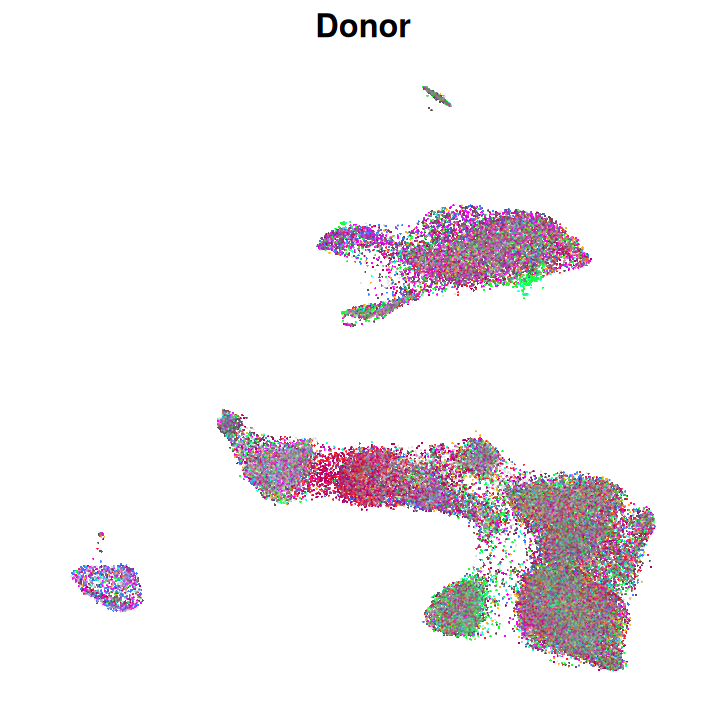

In [ ]:
seu[[]] %>% colnames()h = 6, repr.plot.height = 6)

plot <- embedding.plot(
  seu,
  colour = "donor",
  cmap = pals::polychrome(9) |> set_names(sort(unique(seu$donor))),
  labs = list(title = "Donor"),
  show.legend = FALSE,
  rasterise = TRUE,
  size.adj = 4,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  filename = "../results/plots/kaufmann_natalizumab_all_donor_umap.pdf",
  plot = plot,
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Visualise cell types

Warning message:
"There was 1 warning in `reframe()`.
i In argument: `{ ... }`.
i In group 6: `cluster_coarse = ILC`.
Caused by warning in `KernSmooth::bkde2D()`:
! Binning grid too coarse for current (small) bandwidth: consider increasing 'gridsize'"
Inferred data type as 'discrete'. To override, set type explicitly.



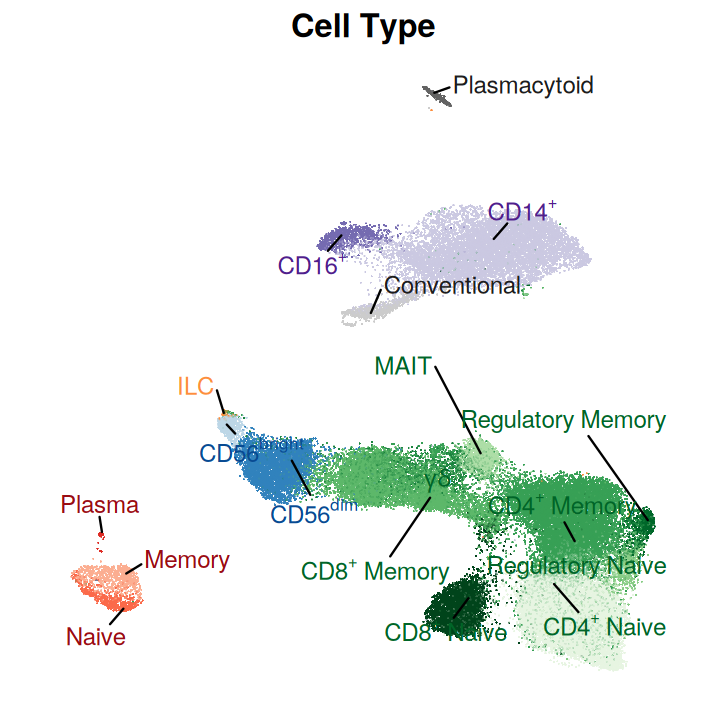

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "cluster_coarse", "cluster_main"))
labels <- data %>%
  group_by(cluster_coarse) %>%
  summarise(cluster_main = first(cluster_main)) %>%
  left_join(calculate.centroid.density(data, group.var = "cluster_coarse", x.var = "umap_1", y.var = "umap_2"), by = "cluster_coarse") %>%
  mutate(
    cluster_coarse = case_match(
      as.character(cluster_coarse),
      "B_naive" ~ "Naive",
      "B_memory" ~ "Memory",
      "B_plasma" ~ "Plasma",
      "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
      "DC_conventional" ~ "Conventional",
      "DC_plasmacytoid" ~ "Plasmacytoid",
      "ILC" ~ "ILC",
      "Mono_CD14" ~ "CD14^'+'",
      "Mono_CD16" ~ "CD16^'+'",
      "NK_CD56dim" ~ "CD56^dim",
      "NK_CD56bright" ~ "CD56^bright",
      "T_CD4_naive" ~ "CD4^'+'~Naive",
      "T_CD4_memory" ~ "CD4^'+'~Memory",
      "T_regulatory_naive" ~ "Regulatory~Naive",
      "T_regulatory_memory" ~ "Regulatory~Memory",
      "T_CD8_naive" ~ "CD8^'+'~Naive",
      "T_CD8_memory" ~ "CD8^'+'~Memory",
      "T_MAIT" ~ "MAIT",
      "T_GD" ~ "gamma*delta",
      "T_DN" ~ "CD4^'-'*CD8^'-'"
    )
  )

plot <- embedding.plot(data, colour = "cluster_coarse", cmap = cluster.pal, labs = list(title = "Cell Type", colour = NULL), show.legend = FALSE, rasterise = TRUE, size.adj = 4, alpha = 1, pixels = c(2048, 2048)) +
  ggrepel::geom_text_repel(
    data = labels,
    mapping = aes(x = x, y = y, colour = cluster_main, label = cluster_coarse),
    segment.colour = "black",
    box.padding = 0.75,
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0,
    seed = 42,
    parse = TRUE,
    show.legend = FALSE
  ) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank(),
    plot.title = element_text(face = "bold", hjust = 0.5)
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_natalizumab_all_cell_type_umap.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Global

### Visualise perturbation effects of treatment

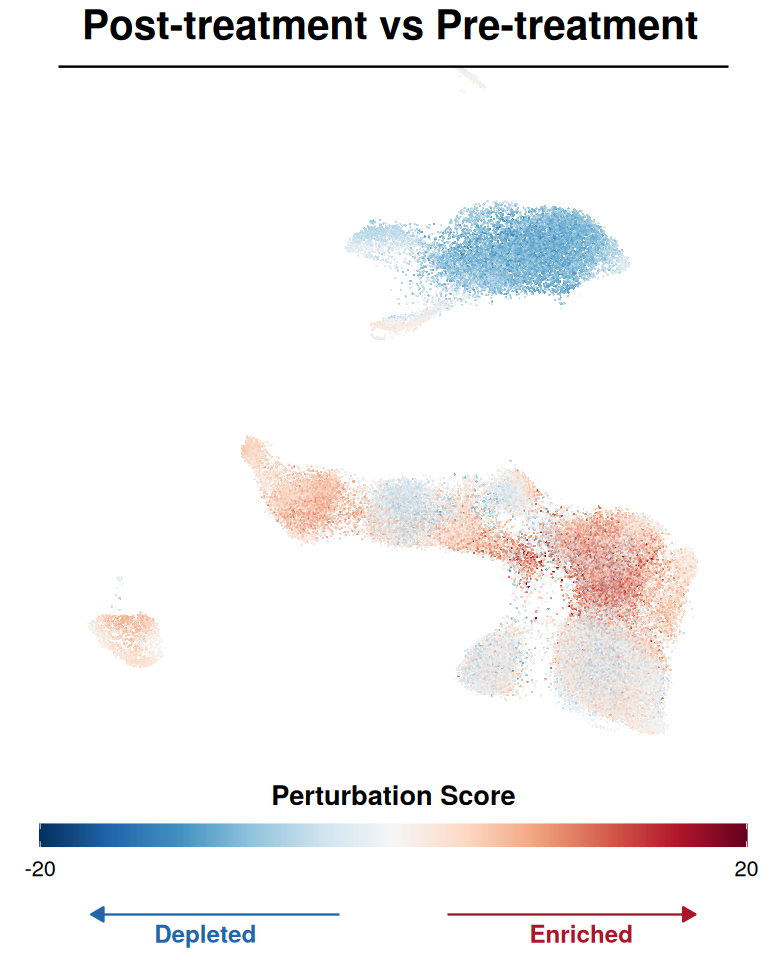

In [ ]:
options(repr.plot.width = 6.5, repr.plot.height = 8)

cond <- c("Post")
plots <- set_names(cond) %>%
  map(
    .f = function(x, data, stats) {
      data <- data %>%
        bind_cols(stats[[x]][rownames(data), ])
      p <- embedding.plot(
        data,
        colour = "z",
        cmap = rev(pals::brewer.rdbu(100)),
        type = "diverging",
        limits = c(-20, 20),
        breaks = c(-20, 20),
        labs = list(colour = "Perturbation Score"),
        verbose = FALSE,
        rasterise = TRUE,
        size.adj = 4,
        alpha = 1,
        pixels = c(2048, 2048)
      ) +
        scale_y_continuous(expand = c(0, 0)) +
        annotate(
          "segment",
          x = -Inf, xend = Inf,
          y = Inf, yend = Inf,
          colour = "black",
          size = 1,
          linetype = 1
        ) +
        theme(
          panel.border = element_blank(),
          axis.title = element_blank(),
          plot.title = element_text(face = "bold", hjust = 0.5),
          legend.position = "none",
          plot.margin = margin(5, 5, 5, 5, "pt")
        )

      return(p)
    },
    data = FetchData(seu, vars = c("umap_1", "umap_2")),
    stats = meld.stats
  )

annotation.arrow <- ggplot() +
  geom_segment(aes(x = 0.42, xend = 0.05, y = 0.7, yend = 0.7),
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    linewidth = 0.5, color = pals::brewer.rdbu(100)[90]
  ) +
  geom_segment(aes(x = 0.58, xend = 0.95, y = 0.7, yend = 0.7),
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    linewidth = 0.5, color = pals::brewer.rdbu(100)[10]
  ) +
  geom_text(aes(x = 0.22, y = 0.3, label = "Depleted"),
    hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[90], fontface = "bold"
  ) +
  geom_text(aes(x = 0.78, y = 0.3, label = "Enriched"),
    hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[10], fontface = "bold"
  ) +
  xlim(0, 1) +
  ylim(0, 1) +
  theme_void()

plot.combined <- plots[["Post"]] +
  theme(
    legend.position = "bottom",
    legend.title.position = "top",
    legend.direction = "horizontal",
    legend.title = element_text(vjust = 1, face = "bold", hjust = 0.5),
    legend.key.width = unit(3, "cm"),
    legend.key.height = unit(0.5, "cm"),
    legend.margin = margin(t = 10, b = 5)
  )

final.plot <- plot.combined / annotation.arrow +
  plot_layout(heights = c(10, 0.8)) +
  plot_annotation(
    title = "Post-treatment vs Pre-treatment",
    theme = theme(
      plot.title = element_text(size = 24, face = "bold", hjust = 0.5)
    )
  )

final.plot

ggsave(
  plot = final.plot,
  filename = "../results/plots/kaufmann_all_perturbation_scores_umap.pdf",
  width = 6.5,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

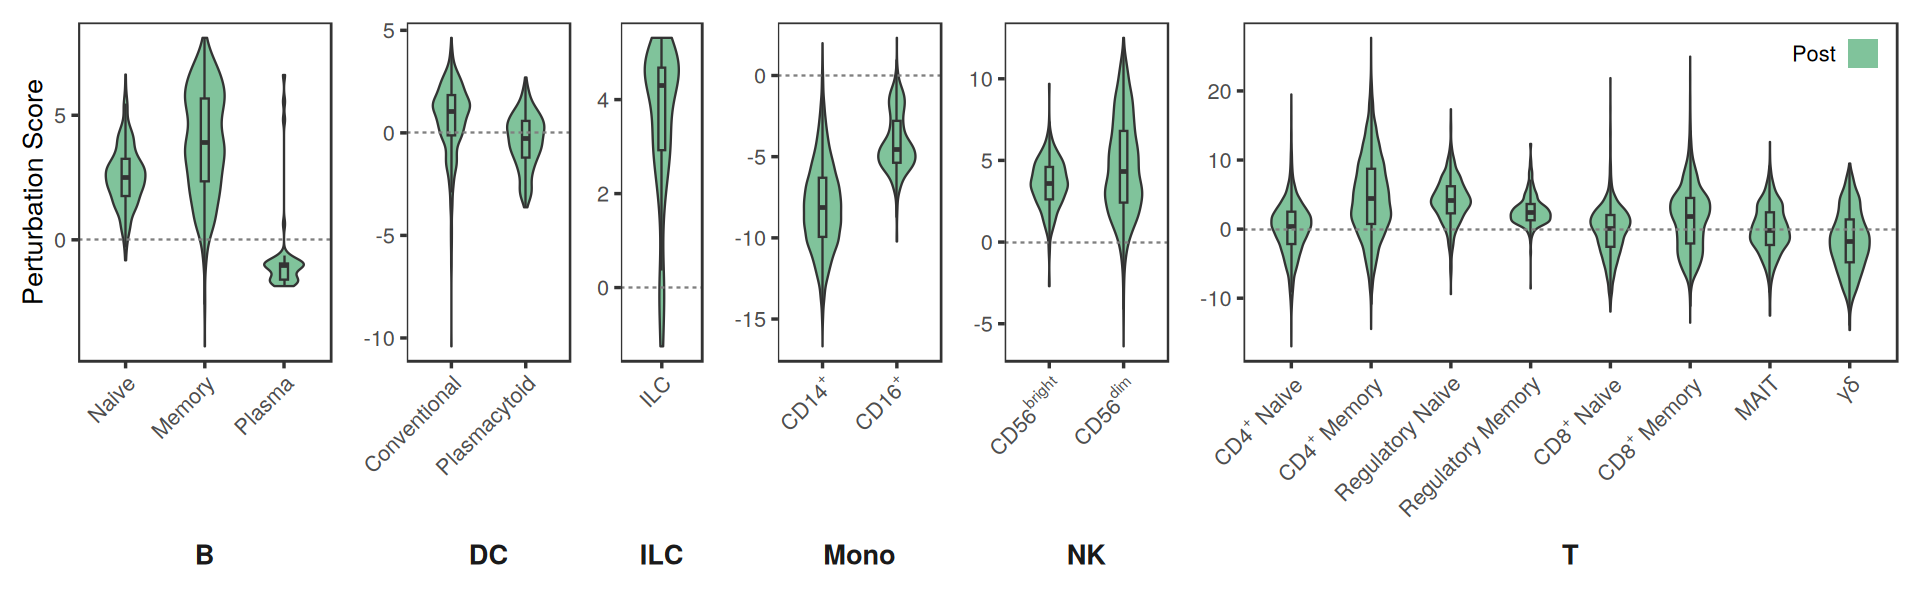

In [ ]:
options(repr.plot.width = 16, repr.plot.height = 5)

cond <- c("Post")
data.combined <- map_dfr(cond, function(x) {
  FetchData(seu, vars = c("cluster_main", "cluster_coarse")) %>%
    bind_cols(meld.stats[[x]]) %>%
    mutate(
      condition = x,
      perturbation = factor(
        case_when(
          z > 0 & q_adj < 1e-5 ~ "Enriched",
          z < 0 & q_adj < 1e-5 ~ "Depleted",
          TRUE ~ "No change"
        ),
        levels = c("Depleted", "No change", "Enriched")
      )
    )
}) %>%
  bind_rows() %>%
  mutate(
    cluster_coarse = factor(
      case_match(
        as.character(cluster_coarse),
        "B_naive" ~ "Naive",
        "B_memory" ~ "Memory",
        "B_plasma" ~ "Plasma",
        "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
        "DC_conventional" ~ "Conventional",
        "DC_plasmacytoid" ~ "Plasmacytoid",
        "ILC" ~ "ILC",
        "Mono_CD14" ~ "CD14^'+'",
        "Mono_CD16" ~ "CD16^'+'",
        "NK_CD56bright" ~ "CD56^bright",
        "NK_CD56dim" ~ "CD56^dim",
        "T_CD4_naive" ~ "CD4^'+'~Naive",
        "T_CD4_memory" ~ "CD4^'+'~Memory",
        "T_regulatory_naive" ~ "Regulatory~Naive",
        "T_regulatory_memory" ~ "Regulatory~Memory",
        "T_CD8_naive" ~ "CD8^'+'~Naive",
        "T_CD8_memory" ~ "CD8^'+'~Memory",
        "T_MAIT" ~ "MAIT",
        "T_GD" ~ "gamma*delta",
        "T_DN" ~ "CD4^'-'*CD8^'-'"
      ),
      levels = c(
        "Naive", "Memory", "Plasma",
        "AXL^'+'*SIGLEC6^'+'", "Conventional", "Plasmacytoid",
        "ILC",
        "CD14^'+'", "CD16^'+'",
        "CD56^bright", "CD56^dim",
        "CD4^'+'~Naive", "CD4^'+'~Memory", "Regulatory~Naive", "Regulatory~Memory",
        "CD8^'+'~Naive", "CD8^'+'~Memory", "MAIT", "gamma*delta", "CD4^'-'*CD8^'-'"
      )
    )
  )

plots <- map(
  c("B", "DC", "ILC", "Mono", "NK", "T"),
  function(x, data = data.combined) {
    ggplot(
      data = filter(data, cluster_main == x),
      mapping = aes(x = cluster_coarse, y = z, fill = condition)
    ) +
      geom_violin(scale = "width", width = 0.5, position = position_dodge(width = 0.75), show.legend = FALSE) +
      geom_boxplot(width = 0.1, outlier.shape = NA, position = position_dodge(width = 0.75), key_glyph = "rect") +
      geom_hline(yintercept = 0, linetype = "dashed", color = "gray50") +
      facet_wrap(~cluster_main, strip.position = "bottom") +
      labs(
        title = NULL,
        x = NULL,
        y = if (x == "B") "Perturbation Score" else NULL,
        fill = NULL
      ) +
      scale_x_discrete(labels = function(x) parse(text = x)) +
      scale_fill_manual(breaks = c("Post"), values = pals::brewer.qualseq(9)[4]) +
      theme_custom() +
      theme(
        strip.background = element_blank(),
        strip.placement = "outside",
        strip.text = element_text(size = 16, face = "bold", hjust = 0.5),
        axis.text.x = element_text(angle = 45, hjust = 1),
        plot.title = element_text(face = "bold", hjust = 0.5),
        legend.position = "none"
      )
  }
)

plots[[length(plots)]] <- plots[[length(plots)]] +
  guides(fill = guide_legend(direction = "horizontal", nrow = 1)) +
  inset.legend(location = "topright")

final.plot <- wrap_plots(plots, nrow = 1, widths = c(3.1, 2, 1, 2, 2, 8))

final.plot

ggsave(
  plot = final.plot,
  filename = "../results/plots/kaufmann_all_perturbation_scores_violin.pdf",
  width = 16,
  height = 5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

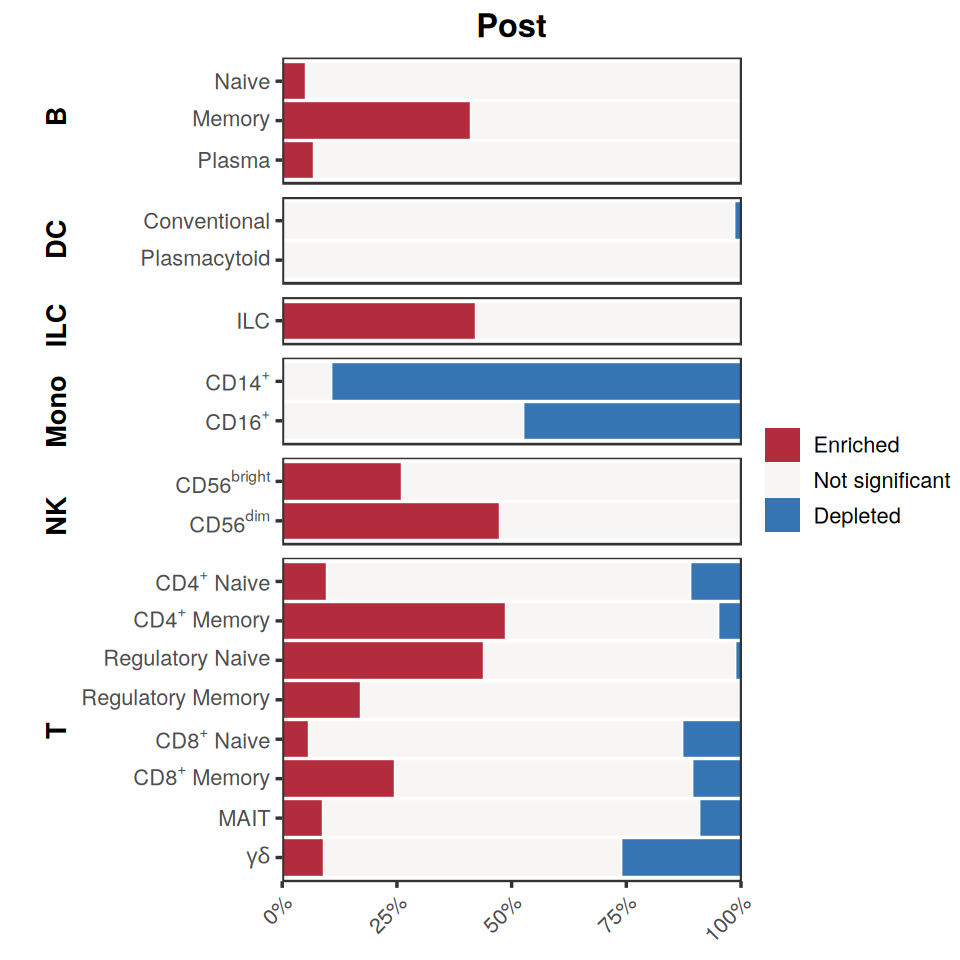

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 8)

cond <- c("Post")
data.combined <- map_dfr(cond, function(x) {
  FetchData(seu, vars = c("cluster_main", "cluster_coarse")) %>%
    bind_cols(meld.stats[[x]]) %>%
    mutate(
      condition = x,
      perturbation = factor(
        case_when(
          z > 0 & q_adj < 1e-5 ~ "Enriched",
          z < 0 & q_adj < 1e-5 ~ "Depleted",
          TRUE ~ "No change"
        ),
        levels = c("Depleted", "No change", "Enriched")
      )
    )
}) %>%
  group_by(cluster_main, cluster_coarse, condition, perturbation) %>%
  summarise(count = n(), .groups = "drop") %>%
  group_by(cluster_main, cluster_coarse, condition) %>%
  mutate(prop = count / sum(count)) %>%
  ungroup()

plots <- map(cond, function(x) {
  data.cond <- data.combined %>%
    filter(condition == x) %>%
    mutate(
      cluster_coarse = factor(
        case_match(
          as.character(cluster_coarse),
          "B_naive" ~ "Naive",
          "B_memory" ~ "Memory",
          "B_plasma" ~ "Plasma",
          "DC_AXL_SIGLEC6" ~ "AXL^'+'*SIGLEC6^'+'",
          "DC_conventional" ~ "Conventional",
          "DC_plasmacytoid" ~ "Plasmacytoid",
          "ILC" ~ "ILC",
          "Mono_CD14" ~ "CD14^'+'",
          "Mono_CD16" ~ "CD16^'+'",
          "NK_CD56bright" ~ "CD56^bright",
          "NK_CD56dim" ~ "CD56^dim",
          "T_CD4_naive" ~ "CD4^'+'~Naive",
          "T_CD4_memory" ~ "CD4^'+'~Memory",
          "T_regulatory_naive" ~ "Regulatory~Naive",
          "T_regulatory_memory" ~ "Regulatory~Memory",
          "T_CD8_naive" ~ "CD8^'+'~Naive",
          "T_CD8_memory" ~ "CD8^'+'~Memory",
          "T_MAIT" ~ "MAIT",
          "T_GD" ~ "gamma*delta",
          "T_DN" ~ "CD4^'-'*CD8^'-'"
        ),
        levels = c(
          "Naive", "Memory", "Plasma",
          "AXL^'+'*SIGLEC6^'+'", "Conventional", "Plasmacytoid",
          "ILC",
          "CD14^'+'", "CD16^'+'",
          "CD56^bright", "CD56^dim",
          "CD4^'+'~Naive", "CD4^'+'~Memory", "Regulatory~Naive", "Regulatory~Memory",
          "CD8^'+'~Naive", "CD8^'+'~Memory", "MAIT", "gamma*delta", "CD4^'-'*CD8^'-'"
        )
      )
    )

  ggplot(data = data.cond, mapping = aes(x = prop, y = cluster_coarse, fill = perturbation)) +
    geom_col(width = 0.95, color = "white", size = 0.3, alpha = 0.9) +
    facet_grid(rows = vars(cluster_main), scales = "free", space = "free") +
    labs(
      title = x,
      x = NULL,
      y = NULL
    ) +
    scale_x_continuous(
      labels = scales::percent_format(accuracy = 1),
      expand = expansion(mult = c(0, 0))
    ) +
    scale_y_discrete(labels = function(x) parse(text = x), limits = rev) +
    scale_fill_manual(
      values = c(
        "Depleted" = pals::brewer.rdbu(100)[90],
        "No change" = pals::brewer.rdbu(100)[50],
        "Enriched" = pals::brewer.rdbu(100)[10]
      )
    ) +
    theme_custom() +
    theme(
      strip.background = element_blank(),
      strip.text = element_blank(),
      axis.text.x = element_text(angle = 45, hjust = 1),
      axis.text.y = if (x == "Post") element_text(hjust = 1, vjust = 0.5) else element_blank(),
      plot.title = element_text(face = "bold", hjust = 0.5),
      legend.position = "none"
    )
})

data.legend <- data.frame(
  perturbation = factor(c("Enriched", "No change", "Depleted"),
    levels = c("Enriched", "No change", "Depleted")
  ),
  y = 1
)

plot.legend <- ggplot(data.legend, aes(x = perturbation, y = y, fill = perturbation)) +
  geom_col(alpha = 0.9) +
  scale_fill_manual(
    values = c(
      "Enriched" = pals::brewer.rdbu(100)[10],
      "No change" = pals::brewer.rdbu(100)[50],
      "Depleted" = pals::brewer.rdbu(100)[90]
    ),
    labels = c("Enriched", "Not significant", "Depleted")
  ) +
  guides(fill = guide_legend(
    title = NULL,
    keywidth = unit(0.75, "cm"),
    keyheight = unit(0.75, "cm")
  )) +
  theme_custom()

legend <- ggpubr::get_legend(plot.legend)

annotation <- ggplot(data = seu[[c("cluster_main", "cluster_coarse")]] %>% distinct(), mapping = aes(y = fct_rev(cluster_coarse))) +
  facet_grid(rows = vars(cluster_main), scales = "free", space = "free") +
  theme_void() +
  theme(
    strip.text.y = element_text(size = 16, face = "bold", angle = 90),
    panel.spacing = unit(0.5, "cm")
  )

plot.combined <- plot_grid(annotation, plots[[1]], legend, nrow = 1, axis = "tblr", align = "h", rel_widths = c(0.1, 1, 0.3))

plot.combined

ggsave(
  plot = plot.combined,
  filename = "../results/plots/kaufmann_all_perturbation_scores_bar.pdf",
  width = 8,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# T cells

In [28]:
# Subset to T cells only
sub <- subset(seu, subset = cluster_main == "T")

In [29]:
sub[["GEP"]] <- CreateAssayObject(data = gep.usage[["T"]][, Cells(sub)])

Warning message:
"Layer counts isn't present in the assay object; returning NULL"


### Visualise T cells

Inferred data type as 'discrete'. To override, set type explicitly.



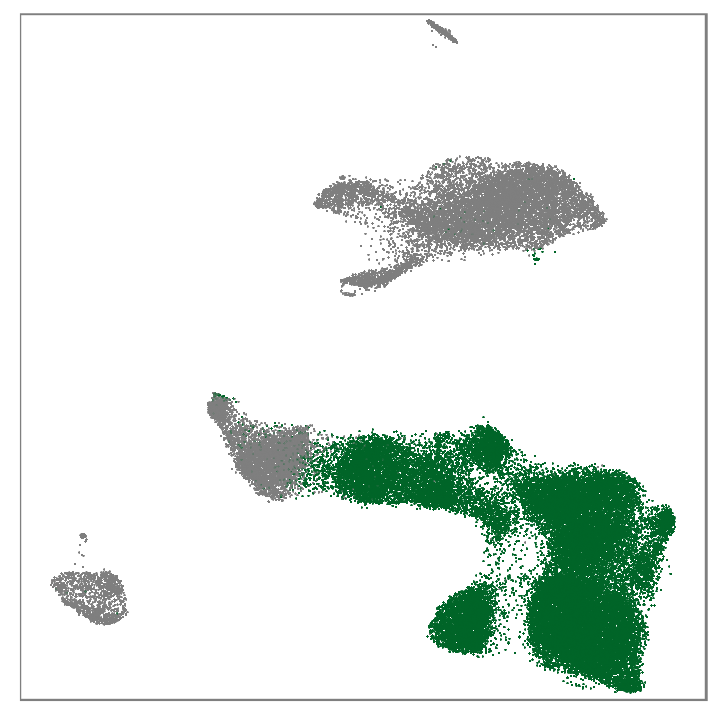

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "cluster_main")) %>%
  mutate(
    cluster_main = if_else(cluster_main == "T", "T", NA_character_)
  )

plot <- embedding.plot(data, colour = "cluster_main", cmap = cluster.pal, show.legend = FALSE, rasterise = TRUE, size.adj = 4, alpha = 1, pixels = c(2048, 2048)) +
  scale_y_continuous(expand = c(0.01, 0.01)) +
  theme(
    axis.title = element_blank(),
    panel.border = element_rect(colour = "grey50")
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_t_cell_type_umap_global.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Recompute UMAP

In [9]:
sub <- sub %>%
  RunUMAP(
    reduction = "integrated.rna",
    dims = 1:50,
    metric = "cosine",
    n.neighbors = 30L,
    min.dist = 0.3,
    spread = 1,
    n.epochs = 200L
  )

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"


16:24:31 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

16:24:31 Read 38873 rows and found 50 numeric columns

16:24:31 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

16:24:31 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:24:36 Writing NN index file to temp file /tmp/RtmphiVTLW/file8daa4038d406

16:24:36 Searching Annoy index using 1 thread, search_k = 3000

16:25:00 Annoy recall = 100%

16:25:01 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:25:05 Initializing from normalized Laplacian + 

### Visualise cell types

Inferred data type as 'discrete'. To override, set type explicitly.



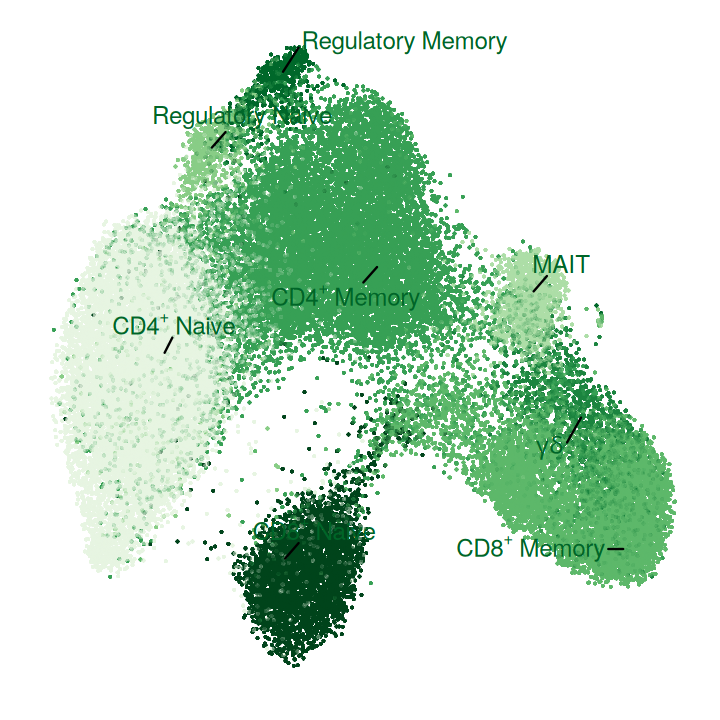

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(sub, vars = c("umap_1", "umap_2", "cluster_coarse", "cluster_main"))
labels <- data %>%
  group_by(cluster_coarse) %>%
  summarise(cluster_main = first(cluster_main)) %>%
  left_join(calculate.centroid.density(data, group.var = "cluster_coarse", x.var = "umap_1", y.var = "umap_2"), by = "cluster_coarse") %>%
  mutate(
    cluster_coarse = case_match(
      as.character(cluster_coarse),
      "T_CD4_naive" ~ "CD4^'+'~Naive",
      "T_CD4_memory" ~ "CD4^'+'~Memory",
      "T_regulatory_naive" ~ "Regulatory~Naive",
      "T_regulatory_memory" ~ "Regulatory~Memory",
      "T_CD8_naive" ~ "CD8^'+'~Naive",
      "T_CD8_memory" ~ "CD8^'+'~Memory",
      "T_MAIT" ~ "MAIT",
      "T_GD" ~ "gamma*delta",
      "T_DN" ~ "CD4^'-'*CD8^'-'"
    )
  )

plot <- embedding.plot(data, colour = "cluster_coarse", cmap = cluster.pal, show.legend = FALSE, rasterise = TRUE, size.adj = 7, alpha = 1, pixels = c(2048, 2048)) +
  ggrepel::geom_text_repel(
    data = labels,
    mapping = aes(x = x, y = y, colour = cluster_main, label = cluster_coarse),
    segment.colour = "black",
    box.padding = 0.75,
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0,
    seed = 42,
    parse = TRUE,
    show.legend = FALSE
  ) +
  scale_y_continuous(expand = c(0.05, 0.05)) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank()
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_t_cell_type_umap.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Visualise perturbation effects of treatment

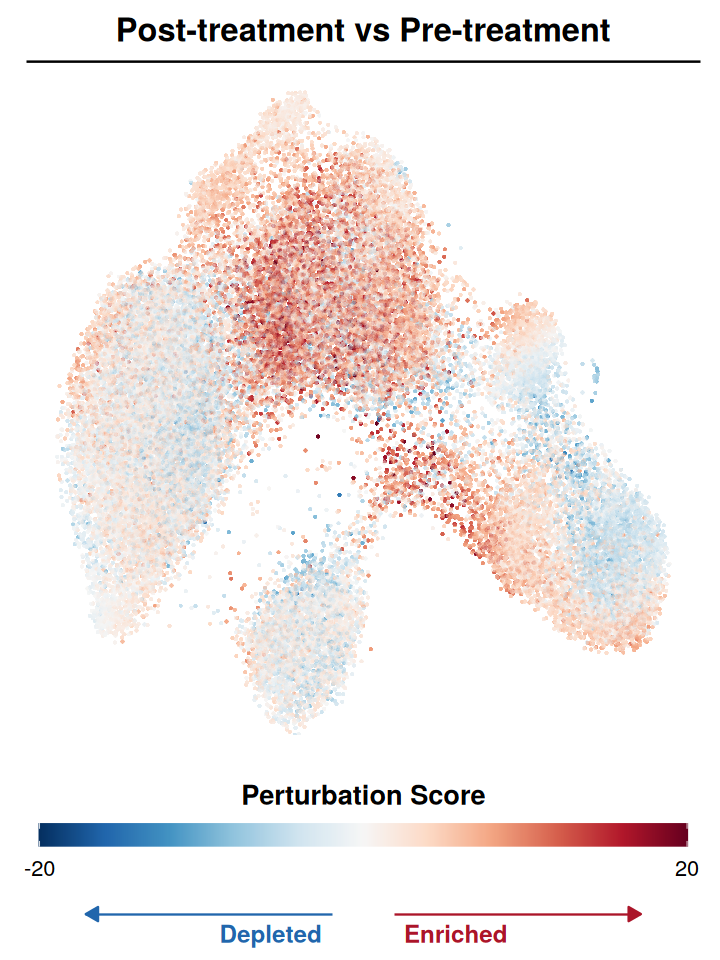

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 8)

cond <- c("Post")
plots <- set_names(cond) %>%
  map(
    .f = function(x, data, stats) {
      data <- data %>%
        bind_cols(stats[[x]][rownames(data), ])
      p <- embedding.plot(
        data,
        colour = "z",
        cmap = rev(pals::brewer.rdbu(100)),
        type = "diverging",
        limits = c(-20, 20),
        breaks = c(-20, 20),
        labs = list(title = "Post-treatment vs Pre-treatment", colour = "Perturbation Score"),
        verbose = FALSE,
        rasterise = TRUE,
        size.adj = 7,
        alpha = 1,
        pixels = c(2048, 2048)
      ) +
        scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
        annotate(
          "segment",
          x = -Inf, xend = Inf,
          y = Inf, yend = Inf,
          colour = "black",
          size = 1,
          linetype = 1
        ) +
        theme(
          panel.border = element_blank(),
          axis.title = element_blank(),
          plot.title = element_text(face = "bold", hjust = 0.5),
          legend.position = "bottom",
          legend.title.position = "top",
          legend.direction = "horizontal",
          legend.title = element_text(vjust = 1, face = "bold", hjust = 0.5),
          legend.key.width = unit(2.75, "cm"),
          legend.key.height = unit(0.5, "cm"),
          legend.margin = margin(t = 10, b = 5),
          plot.margin = margin(5, 5, 5, 5, "pt")
        )
      return(p)
    },
    data = FetchData(sub, vars = c("umap_1", "umap_2")),
    stats = meld.stats
  )

annotation.arrow <- ggplot() +
  geom_segment(aes(x = 0.45, xend = 0.05, y = 0.7, yend = 0.7),
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    linewidth = 0.5, color = pals::brewer.rdbu(100)[90]
  ) +
  geom_segment(aes(x = 0.55, xend = 0.95, y = 0.7, yend = 0.7),
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    linewidth = 0.5, color = pals::brewer.rdbu(100)[10]
  ) +
  geom_text(aes(x = 0.35, y = 0.3, label = "Depleted"),
    hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[90], fontface = "bold"
  ) +
  geom_text(aes(x = 0.65, y = 0.3, label = "Enriched"),
    hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[10], fontface = "bold"
  ) +
  xlim(0, 1) +
  ylim(0, 1) +
  theme_void()

final.plot <- plots[[1]] / annotation.arrow +
  plot_layout(heights = c(10, 0.8))

final.plot <- ggrastr::rasterise(final.plot, layers = "Point", dpi = 600)

final.plot

ggsave(
  plot = final.plot,
  filename = "../results/plots/kaufmann_t_perturbation_scores_umap.pdf",
  width = 6,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Program effect scores

In [ ]:
shap <- read.table(
  file = "../results/tables/external/kaufmann/shap/T/Post.tsv",
  sep = "\t",
  header = TRUE,
  row.names = 1,
  check.names = FALSE
)

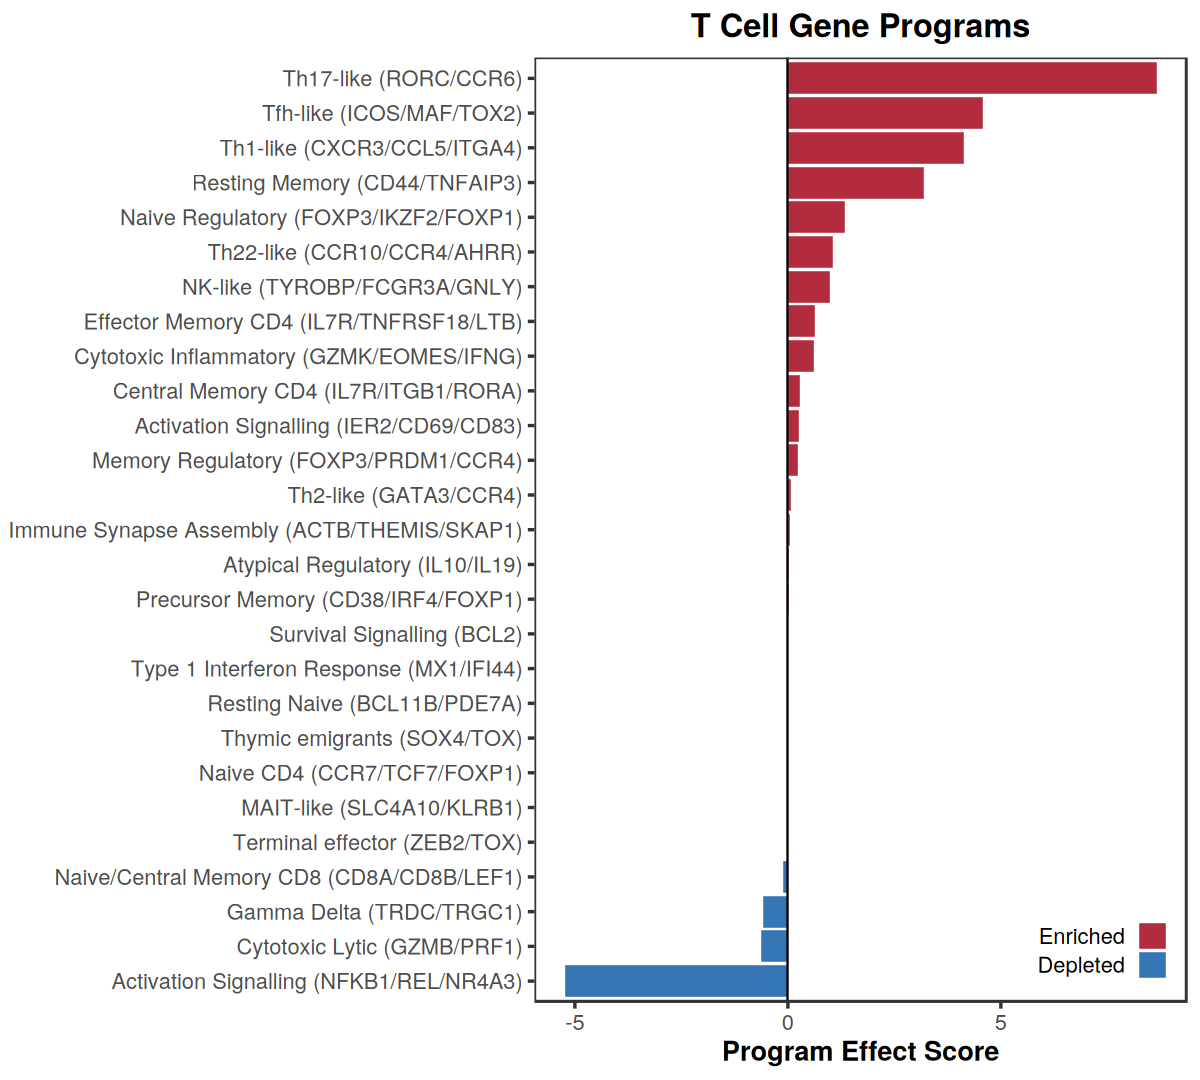

In [ ]:
options(repr.plot.width = 10, repr.plot.height = 9)

data <- map_dfr(
  .x = grep(pattern = "Housekeeping|Contamination|Artefactual", x = colnames(shap), value = TRUE, invert = TRUE),
  .f = function(x,
                shap.df = shap,
                gep.df = as.data.frame(t(gep.usage[["T"]]))[rownames(shap), , drop = FALSE],
                perturbation.scores = meld.stats[["Post"]][rownames(shap), "z", drop = TRUE],
                threshold = 0.2) {
    usage <- gep.df[[x]]
    shap.values <- shap.df[[x]]
    idx <- which(usage > threshold)
    mean.abs.shap <- mean(abs(shap.values[idx]))
    mean.perturbation <- mean(perturbation.scores[idx])
    return(list(
      program = x,
      mean_abs_shap = mean.abs.shap,
      mean_perturbation = mean.perturbation,
      program_effect_score = mean.abs.shap * mean.perturbation
    ))
  }
) %>%
  mutate(effect_direction = case_when(
    mean_perturbation > 0 ~ "Enriched",
    mean_perturbation < 0 ~ "Depleted",
    TRUE ~ "No change"
  ))

plot <- ggplot(data = data, mapping = aes(x = program_effect_score, y = reorder(program, program_effect_score), fill = effect_direction)) +
  geom_col(width = 0.95, color = "white", size = 0.3, alpha = 0.9) +
  labs(
    title = "T Cell Gene Programs",
    x = "Program Effect Score",
    y = NULL,
    fill = NULL
  ) +
  scale_x_continuous(expand = expansion(mult = c(0.05, 0.05))) +
  geom_vline(xintercept = 0, color = "black") +
  scale_fill_manual(
    values = c(
      "Depleted" = pals::brewer.rdbu(100)[90],
      "No change" = pals::brewer.rdbu(100)[50],
      "Enriched" = pals::brewer.rdbu(100)[10]
    ),
    breaks = c("Enriched", "Depleted")
  ) +
  theme_custom() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    legend.position = "top",
    legend.title = element_text(face = "bold")
  ) +
  inset.legend(location = "bottomright")

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_t_program_effect_scores_bar.pdf",
  width = 10,
  height = 9,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Donor-level program score comparisons

In [ ]:
plots <- list()

### Th17-like

In [ ]:
chosen.gep <- Features(sub[["GEP"]])[16]
chosen.gep

[1] "Th17-like (RORC/CCR6)"

In [ ]:
sub$program_score <- GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, , drop = TRUE]

Inferred data type as 'sequential'. To override, set type explicitly.



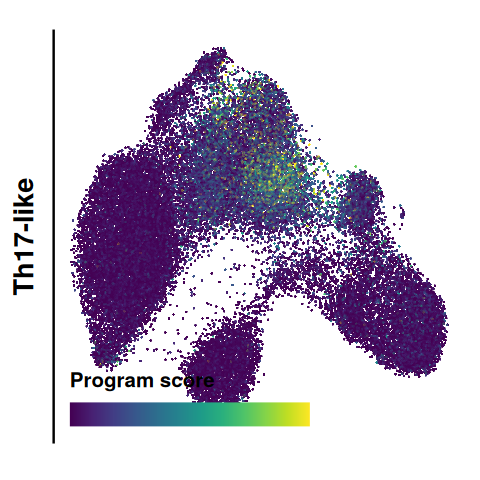

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 4)

plot <- embedding.plot(
  sub,
  colour = "program_score",
  cmap = pals::viridis(100),
  labs = list(y = "Th17-like"),
  show.legend = TRUE,
  rasterise = TRUE,
  limits = c(NA, "p99"),
  size.adj = 7,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  geom_vline(xintercept = -Inf, color = "black", size = 1) +
  guides(
    color = guide_colorbar(title = "Program score", direction = "horizontal", title.position = "top", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)
  ) +
  inset.legend(location = "bottomleft") +
  theme(
    legend.ticks = element_blank(),
    panel.border = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_text(face = "bold"),
    legend.text.position = "bottom",
    legend.title = element_text(face = "bold", size = 12),
    legend.text = element_blank()
  )

plot

ggsave(
  filename = "../results/plots/kaufmann_natalizumab_th17like_program_score_umap.pdf",
  width = 4,
  height = 4,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

In [ ]:
data <- FetchData(sub, vars = c("donor", "condition", "cluster_coarse", "program_score")) %>%
  left_join(donor.metadata, by = "donor")  %>% 
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory"))

data.summary <- data %>%
  group_by(donor, condition) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [ ]:
model <- lmerTest::lmer(
  program_score ~ condition + age + sex + (1 | donor),
  data = data.summary
)

In [ ]:
emm <- emmeans::emmeans(model, ~ condition, lmer.df = "Satterthwaite")

contrasts <- list(
  "Post vs Pre" = c(-1, 1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.06
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Post vs Pre,0.004436501,0.001306654,8,0.001423352,0.007449651,3.395314,0.00942556,0.00942556,p = 9.43e-03 **,Post,Pre,0.06


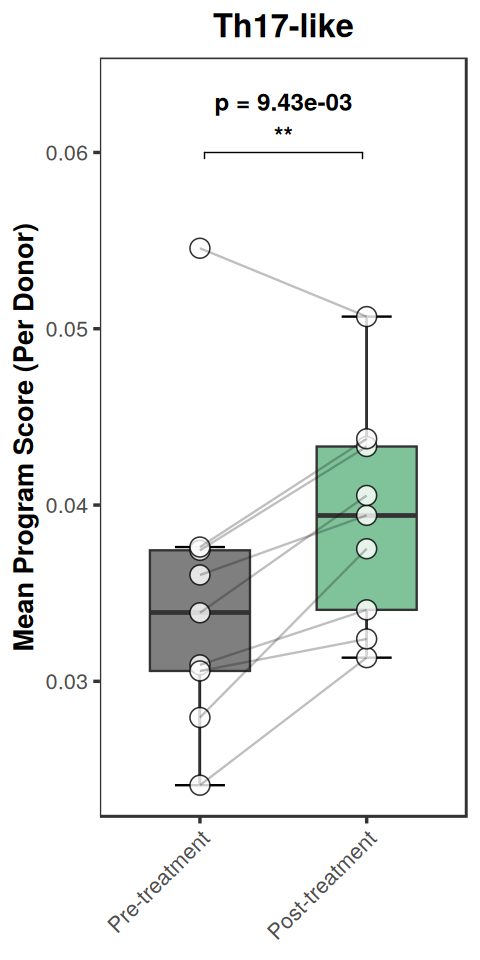

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 8)

plots[[1]] <- ggplot(data = data.summary, mapping = aes(x = condition, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = condition),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    data = data.summary,
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    data = data.summary,
    mapping = aes(group = donor),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(labels = c("Pre" = "Pre-treatment", "Post" = "Post-treatment")) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c("grey50", pals::brewer.qualseq(8)[4])) +
  labs(
    title = "Th17-like",
    subtitle = NULL,
    x = NULL,
    y = "Mean Program Score (Per Donor)"
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold", color = "grey20", margin = margin(6, 6, 6, 6)),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    panel.spacing = unit(5, "mm")
  )

plots[[1]]

### Tfh-like

In [ ]:
chosen.gep <- Features(sub[["GEP"]])[11]
chosen.gep

[1] "Tfh-like (ICOS/MAF/TOX2)"

In [ ]:
sub$program_score <- GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, , drop = TRUE]

Inferred data type as 'sequential'. To override, set type explicitly.



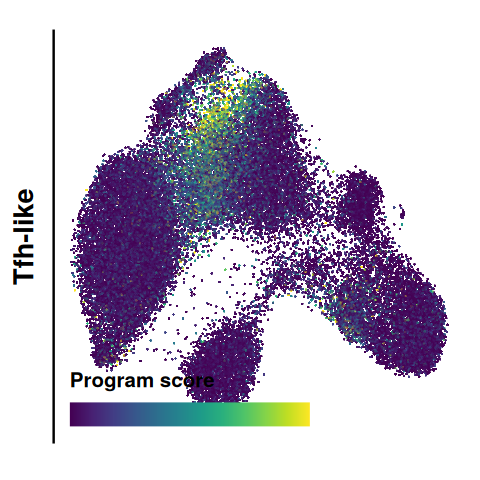

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 4)

plot <- embedding.plot(
  sub,
  colour = "program_score",
  cmap = pals::viridis(100),
  labs = list(y = "Tfh-like"),
  show.legend = TRUE,
  rasterise = TRUE,
  limits = c(NA, "p99"),
  size.adj = 7,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  geom_vline(xintercept = -Inf, color = "black", size = 1) +
  guides(
    color = guide_colorbar(title = "Program score", direction = "horizontal", title.position = "top", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)
  ) +
  inset.legend(location = "bottomleft") +
  theme(
    legend.ticks = element_blank(),
    panel.border = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_text(face = "bold"),
    legend.text.position = "bottom",
    legend.title = element_text(face = "bold", size = 12),
    legend.text = element_blank()
  )

plot

ggsave(
  filename = "../results/plots/kaufmann_natalizumab_tfhlike_program_score_umap.pdf",
  width = 4,
  height = 4,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

In [ ]:
data <- FetchData(sub, vars = c("donor", "condition", "cluster_coarse", "program_score")) %>%
  left_join(donor.metadata, by = "donor")  %>% 
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory"))

data.summary <- data %>%
  group_by(donor, condition) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [ ]:
model <- lmerTest::lmer(
  program_score ~ condition + age + sex + (1 | donor),
  data = data.summary
)

In [ ]:
emm <- emmeans::emmeans(model, ~ condition, lmer.df = "Satterthwaite")

contrasts <- list(
  "Post vs Pre" = c(-1, 1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.05
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Post vs Pre,0.005283193,0.001242995,8,0.00241684,0.008149545,4.250372,0.002797738,0.002797738,p = 2.8e-03 **,Post,Pre,0.05


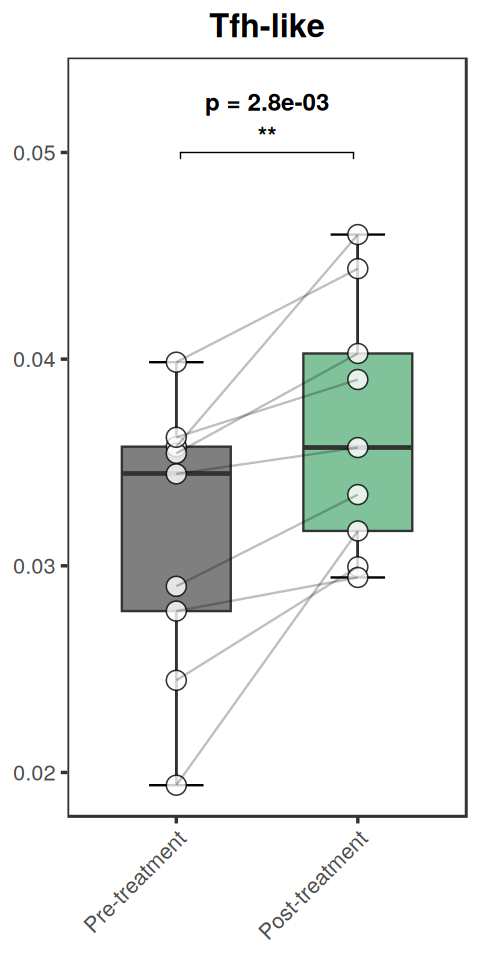

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 8)

plots[[2]] <- ggplot(data = data.summary, mapping = aes(x = condition, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = condition),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    data = data.summary,
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    data = data.summary,
    mapping = aes(group = donor),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(labels = c("Pre" = "Pre-treatment", "Post" = "Post-treatment")) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c("grey50", pals::brewer.qualseq(8)[4])) +
  labs(
    title = "Tfh-like",
    subtitle = NULL,
    x = NULL,
    y = NULL
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold", color = "grey20", margin = margin(6, 6, 6, 6)),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    panel.spacing = unit(5, "mm")
  )

plots[[2]]

### Th1-like

In [ ]:
chosen.gep <- Features(sub[["GEP"]])[13]
chosen.gep

[1] "Th1-like (CXCR3/CCL5/ITGA4)"

In [ ]:
sub$program_score <- GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, , drop = TRUE]

Inferred data type as 'sequential'. To override, set type explicitly.



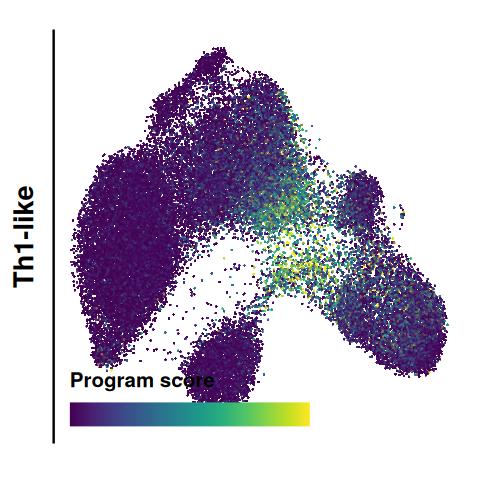

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 4)

plot <- embedding.plot(
  sub,
  colour = "program_score",
  cmap = pals::viridis(100),
  labs = list(y = "Th1-like"),
  show.legend = TRUE,
  rasterise = TRUE,
  limits = c(NA, "p99"),
  size.adj = 7,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  geom_vline(xintercept = -Inf, color = "black", size = 1) +
  guides(
    color = guide_colorbar(title = "Program score", direction = "horizontal", title.position = "top", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)
  ) +
  inset.legend(location = "bottomleft") +
  theme(
    legend.ticks = element_blank(),
    panel.border = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_text(face = "bold"),
    legend.text.position = "bottom",
    legend.title = element_text(face = "bold", size = 12),
    legend.text = element_blank()
  )

plot

ggsave(
  filename = "../results/plots/kaufmann_natalizumab_th1like_program_score_umap.pdf",
  width = 4,
  height = 4,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

In [ ]:
data <- FetchData(sub, vars = c("donor", "condition", "cluster_coarse", "program_score")) %>%
  left_join(donor.metadata, by = "donor")  %>% 
  filter(cluster_coarse %in% c("T_CD4_memory", "T_CD8_memory"))

data.summary <- data %>%
  group_by(donor, condition) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [ ]:
model <- lmerTest::lmer(
  program_score ~ condition + age + sex + (1 | donor),
  data = data.summary
)

In [ ]:
emm <- emmeans::emmeans(model, ~ condition, lmer.df = "Satterthwaite")

contrasts <- list(
  "Post vs Pre" = c(-1, 1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.055
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Post vs Pre,0.006024129,0.002045731,8,0.001306665,0.01074159,2.944732,0.01857471,0.01857471,p = 0.019 *,Post,Pre,0.055


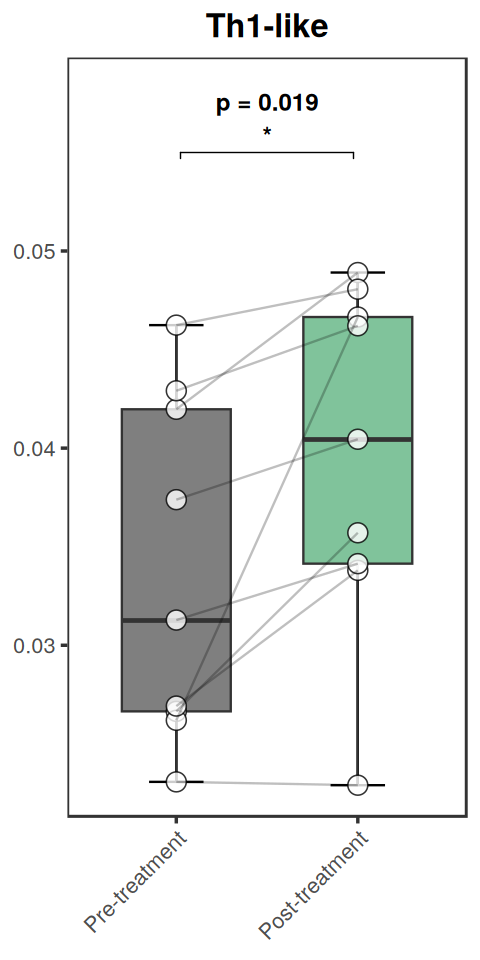

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 8)

plots[[3]] <- ggplot(data = data.summary, mapping = aes(x = condition, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = condition),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    data = data.summary,
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    data = data.summary,
    mapping = aes(group = donor),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(labels = c("Pre" = "Pre-treatment", "Post" = "Post-treatment")) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c("grey50", pals::brewer.qualseq(8)[4])) +
  labs(
    title = "Th1-like",
    subtitle = NULL,
    x = NULL,
    y = NULL
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold", color = "grey20", margin = margin(6, 6, 6, 6)),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    panel.spacing = unit(5, "mm")
  )

plots[[3]]

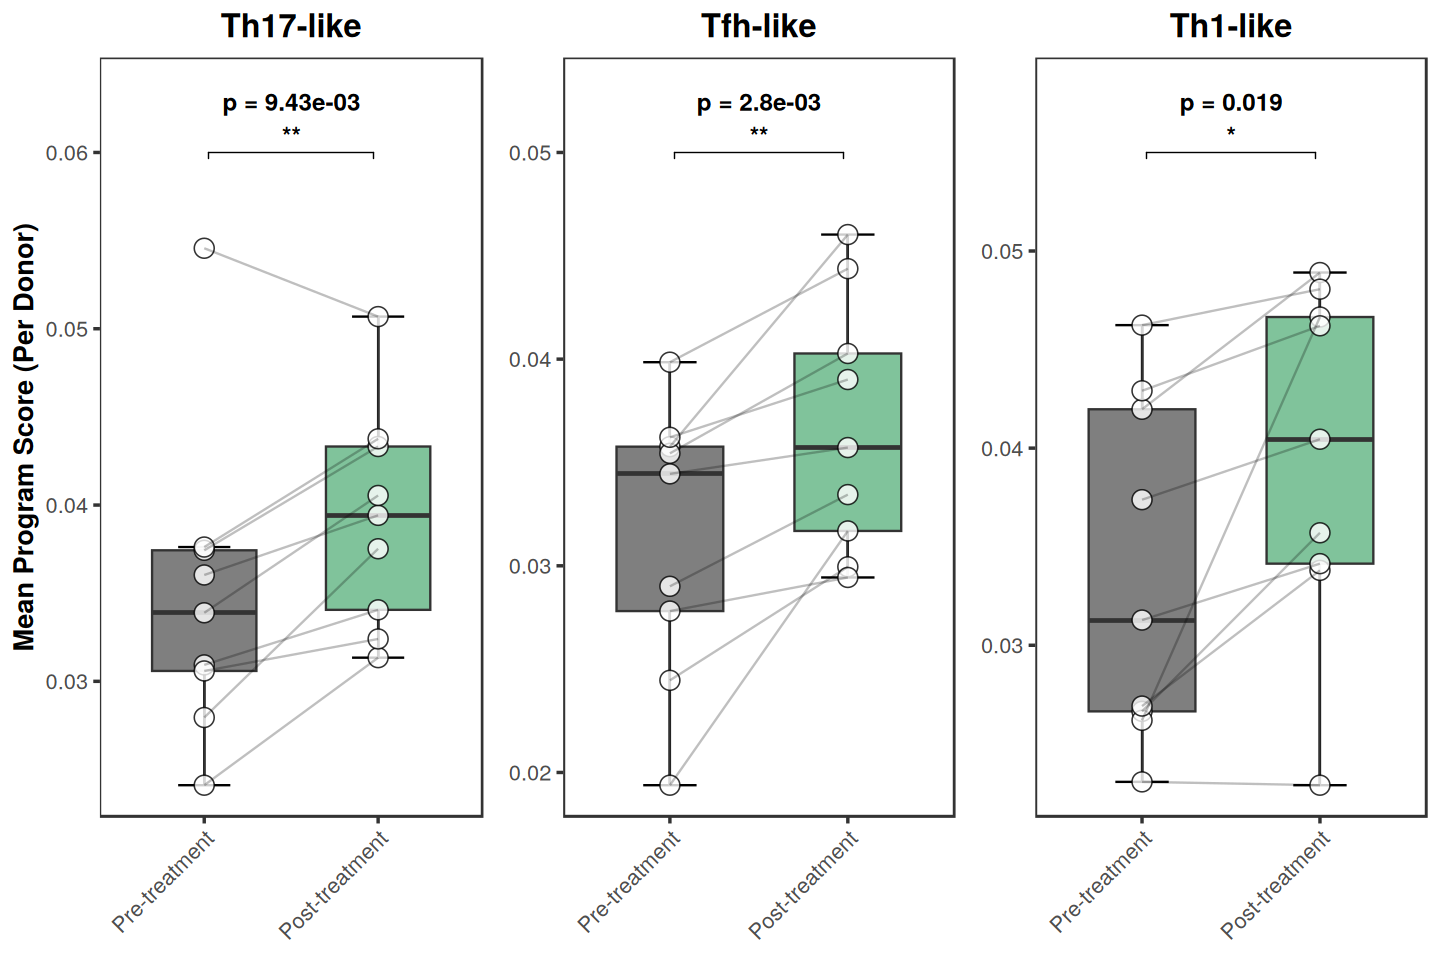

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)

plot.combined <- plot_grid(plotlist = plots, nrow = 1, rel_widths = c(1.05, 1, 1))

plot.combined

ggsave(
  plot = plot.combined,
  filename = "../results/plots/kaufmann_t_program_scores_boxplot.pdf",
  width = 12,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### T~c~1-TH

In [30]:
chosen.gep <- Features(sub[["GEP"]])[c(13, 20, 30)]
chosen.gep

[1] "Th1-like (CXCR3/CCL5/ITGA4)"             
[2] "Cytotoxic Inflammatory (GZMK/EOMES/IFNG)"
[3] "Activation Signalling (IER2/CD69/CD83)"

In [31]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

Inferred data type as 'sequential'. To override, set type explicitly.



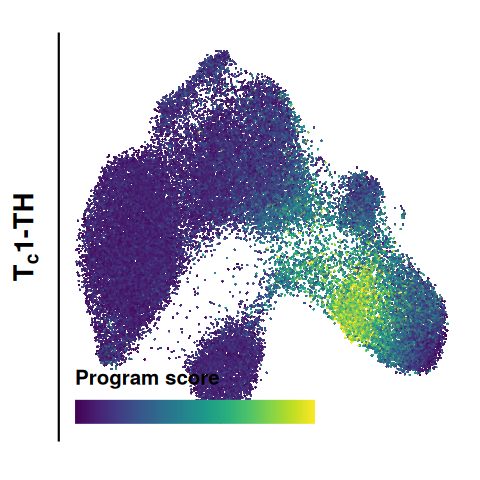

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 4)

plot <- embedding.plot(
  sub,
  colour = "program_score",
  cmap = pals::viridis(100),
  labs = list(y = expression(bold(T[c] * "1-" * TH))),
  show.legend = TRUE,
  rasterise = TRUE,
  limits = c(NA, "p99"),
  size.adj = 7,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  geom_vline(xintercept = -Inf, color = "black", size = 1) +
  guides(
    color = guide_colorbar(title = "Program score", direction = "horizontal", title.position = "top", barwidth = 10, barheight = 1, draw.ulim = FALSE, draw.llim = FALSE)
  ) +
  inset.legend(location = "bottomleft") +
  theme(
    legend.ticks = element_blank(),
    panel.border = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_text(face = "bold"),
    legend.text.position = "bottom",
    legend.title = element_text(face = "bold", size = 12),
    legend.text = element_blank()
  )

plot

ggsave(
  filename = "../results/plots/kaufmann_tc1th_program_score_umap.pdf",
  width = 4,
  height = 4,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

In [ ]:
data <- FetchData(sub, vars = c("donor", "condition", "cluster_coarse", "program_score")) %>%
  left_join(donor.metadata, by = "donor")  %>% 
  filter(cluster_coarse %in% c("T_CD8_memory"))

data.summary <- data %>%
  group_by(donor, condition) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [ ]:
model <- lmerTest::lmer(
  program_score ~ condition + age + sex + (1 | donor),
  data = data.summary
)

In [ ]:
emm <- emmeans::emmeans(model, ~ condition, lmer.df = "Satterthwaite")

contrasts <- list(
  "Post vs Pre" = c(-1, 1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.36
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Post vs Pre,0.03577358,0.008609788,8,0.01591938,0.05562779,4.15499,0.003187057,0.003187057,p = 3.19e-03 **,Post,Pre,0.36


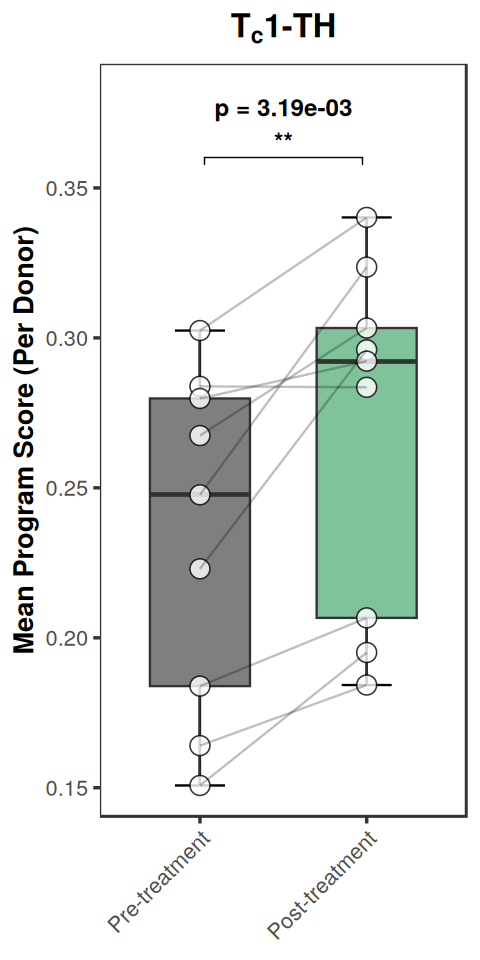

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 8)

plot <- ggplot(data = data.summary, mapping = aes(x = condition, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = condition),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    data = data.summary,
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    data = data.summary,
    mapping = aes(group = donor),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(labels = c("Pre" = "Pre-treatment", "Post" = "Post-treatment")) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c("grey50", pals::brewer.qualseq(8)[4])) +
  labs(
    title = expression(bold(T[c] * "1-" * TH)),
    subtitle = NULL,
    x = NULL,
    y = "Mean Program Score (Per Donor)"
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold", color = "grey20", margin = margin(6, 6, 6, 6)),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    panel.spacing = unit(5, "mm")
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_tc1th_time_point_boxplot.pdf",
  width = 4,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# B cells

In [ ]:
# Subset to B cells only
sub <- subset(seu, subset = cluster_main == "B")
Idents(sub) <- "cluster_fine"

In [ ]:
sub[["GEP"]] <- CreateAssayObject(data = gep.usage[["B"]][, Cells(sub)])

Warning message:
"Layer counts isn't present in the assay object; returning NULL"


### Visualise B cells

Inferred data type as 'discrete'. To override, set type explicitly.



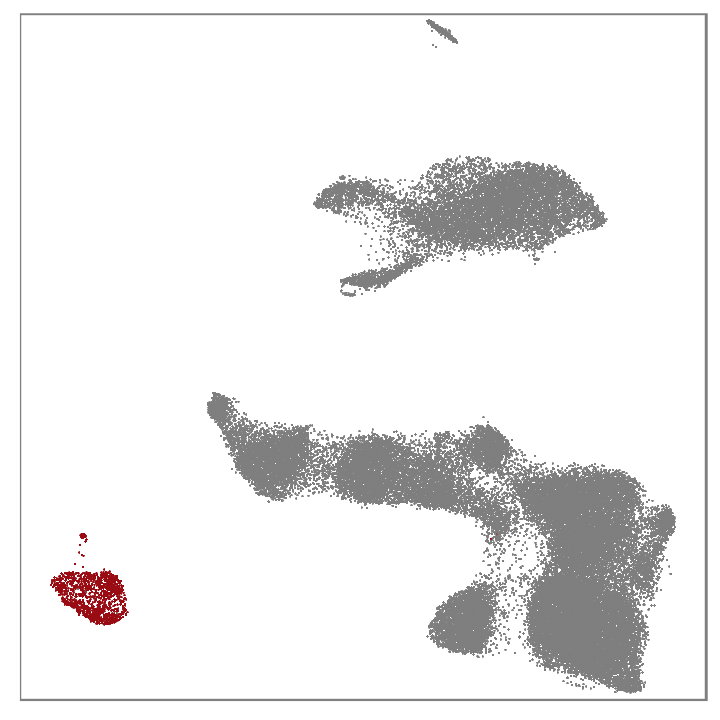

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(seu, vars = c("umap_1", "umap_2", "cluster_main")) %>%
  mutate(
    cluster_main = if_else(cluster_main == "B", "B", NA_character_)
  )

plot <- embedding.plot(data, colour = "cluster_main", cmap = cluster.pal, show.legend = FALSE, rasterise = TRUE, size.adj = 4, alpha = 1, pixels = c(2048, 2048)) +
  scale_y_continuous(expand = c(0.01, 0.01)) +
  theme(
    axis.title = element_blank(),
    panel.border = element_rect(colour = "grey50")
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_b_cell_type_umap_global.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Recompute UMAP projection

In [ ]:
sub <- sub %>%
  RunUMAP(
    reduction = "integrated.rna",
    dims = 1:50,
    metric = "cosine",
    n.neighbors = 30L,
    min.dist = 0.3,
    spread = 1,
    n.epochs = 200L
  )

Warning message:
"The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session"
14:43:28 UMAP embedding parameters a = 0.9922 b = 1.112

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

14:43:28 Read 1259 rows and found 50 numeric columns

14:43:28 Using Annoy for neighbor search, n_neighbors = 30

Found more than one class "dist" in cache; using the first, from namespace 'spam'

Also defined by 'BiocGenerics'

14:43:28 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:43:28 Writing NN index file to t

### Visualise cell types

Inferred data type as 'discrete'. To override, set type explicitly.



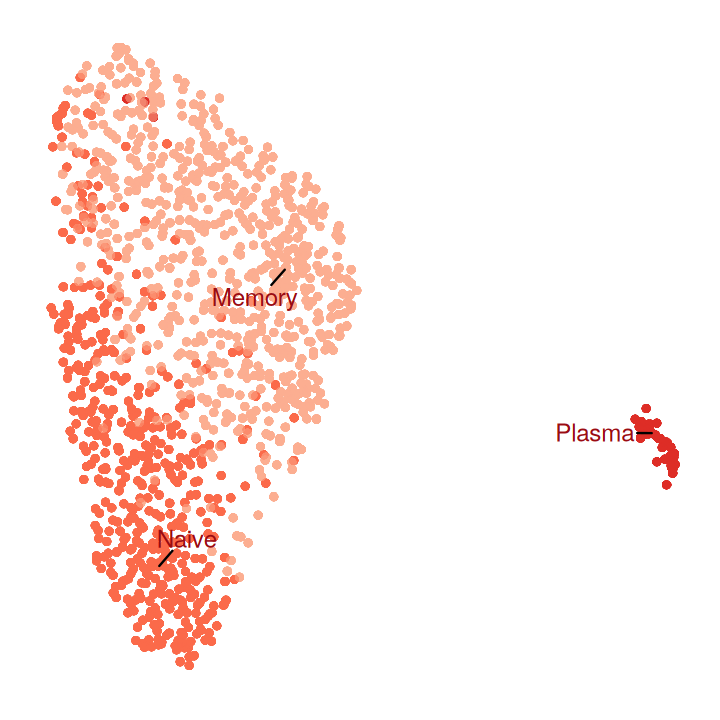

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 6)

data <- FetchData(sub, vars = c("umap_1", "umap_2", "cluster_coarse", "cluster_main"))
labels <- data %>%
  group_by(cluster_coarse) %>%
  summarise(cluster_main = first(cluster_main)) %>%
  left_join(calculate.centroid.density(data, group.var = "cluster_coarse", x.var = "umap_1", y.var = "umap_2"), by = "cluster_coarse") %>%
  mutate(
    cluster_coarse = case_match(
      cluster_coarse,
      "B_naive" ~ "Naive",
      "B_memory" ~ "Memory",
      "B_plasma" ~ "Plasma"
    )
  )

plot <- embedding.plot(data, colour = "cluster_coarse", cmap = cluster.pal, show.legend = FALSE, rasterise = TRUE, size.adj = 15, alpha = 1, pixels = c(2048, 2048)) +
  ggrepel::geom_text_repel(
    data = labels,
    mapping = aes(x = x, y = y, colour = cluster_main, label = cluster_coarse),
    segment.colour = "black",
    box.padding = 0.75,
    size = 5,
    max.overlaps = Inf,
    min.segment.length = 0,
    seed = 42,
    parse = TRUE,
    show.legend = FALSE
  ) +
  scale_y_continuous(expand = c(0.05, 0.05)) +
  theme(
    axis.title = element_blank(),
    panel.border = element_blank()
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_b_cell_type_umap.pdf",
  width = 6,
  height = 6,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Visualise perturbation effects of treatment

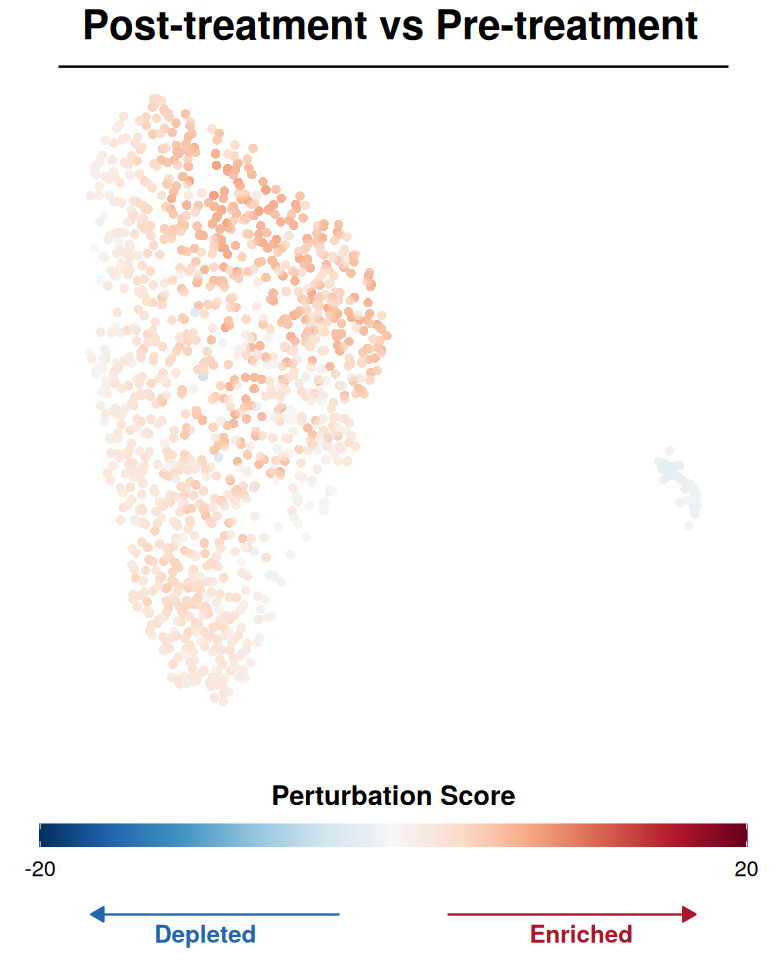

In [ ]:
options(repr.plot.width = 6.5, repr.plot.height = 8)

cond <- c("Post")
plots <- set_names(cond) %>%
  map(
    .f = function(x, data, stats) {
      data <- data %>%
        bind_cols(stats[[x]][rownames(data), ])
      p <- embedding.plot(
        data,
        colour = "z",
        cmap = rev(pals::brewer.rdbu(100)),
        type = "diverging",
        limits = c(-20, 20),
        breaks = c(-20, 20),
        labs = list(colour = "Perturbation Score"),
        verbose = FALSE,
        rasterise = TRUE,
        size.adj = 15,
        alpha = 1,
        pixels = c(2048, 2048)
      ) +
        scale_y_continuous(expand = c(0.05, 0.05)) +
        annotate(
          "segment",
          x = -Inf, xend = Inf,
          y = Inf, yend = Inf,
          colour = "black",
          size = 1,
          linetype = 1
        ) +
        theme(
          panel.border = element_blank(),
          axis.title = element_blank(),
          plot.title = element_text(face = "bold", hjust = 0.5),
          legend.position = "none",
          plot.margin = margin(5, 5, 5, 5, "pt")
        )

      return(p)
    },
    data = FetchData(sub, vars = c("umap_1", "umap_2")),
    stats = meld.stats
  )

annotation.arrow <- ggplot() +
  geom_segment(aes(x = 0.42, xend = 0.05, y = 0.7, yend = 0.7),
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    linewidth = 0.5, color = pals::brewer.rdbu(100)[90]
  ) +
  geom_segment(aes(x = 0.58, xend = 0.95, y = 0.7, yend = 0.7),
    arrow = arrow(length = unit(0.3, "cm"), type = "closed"),
    linewidth = 0.5, color = pals::brewer.rdbu(100)[10]
  ) +
  geom_text(aes(x = 0.22, y = 0.3, label = "Depleted"),
    hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[90], fontface = "bold"
  ) +
  geom_text(aes(x = 0.78, y = 0.3, label = "Enriched"),
    hjust = 0.5, size = 5, color = pals::brewer.rdbu(100)[10], fontface = "bold"
  ) +
  xlim(0, 1) +
  ylim(0, 1) +
  theme_void()

plot.combined <- plots[["Post"]] +
  theme(
    legend.position = "bottom",
    legend.title.position = "top",
    legend.direction = "horizontal",
    legend.title = element_text(vjust = 1, face = "bold", hjust = 0.5),
    legend.key.width = unit(3, "cm"),
    legend.key.height = unit(0.5, "cm"),
    legend.margin = margin(t = 10, b = 5)
  )

final.plot <- plot.combined / annotation.arrow +
  plot_layout(heights = c(10, 0.8)) +
  plot_annotation(
    title = "Post-treatment vs Pre-treatment",
    theme = theme(
      plot.title = element_text(size = 24, face = "bold", hjust = 0.5)
    )
  )

final.plot

ggsave(
  plot = final.plot,
  filename = "../results/plots/kaufmann_b_perturbation_scores_umap.pdf",
  width = 6.5,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Program effect scores

In [ ]:
shap <- read.table(
  file = "../results/tables/external/kaufmann/shap/B/Post.tsv",
  sep = "\t",
  header = TRUE,
  row.names = 1,
  check.names = FALSE
) %>%
  filter()

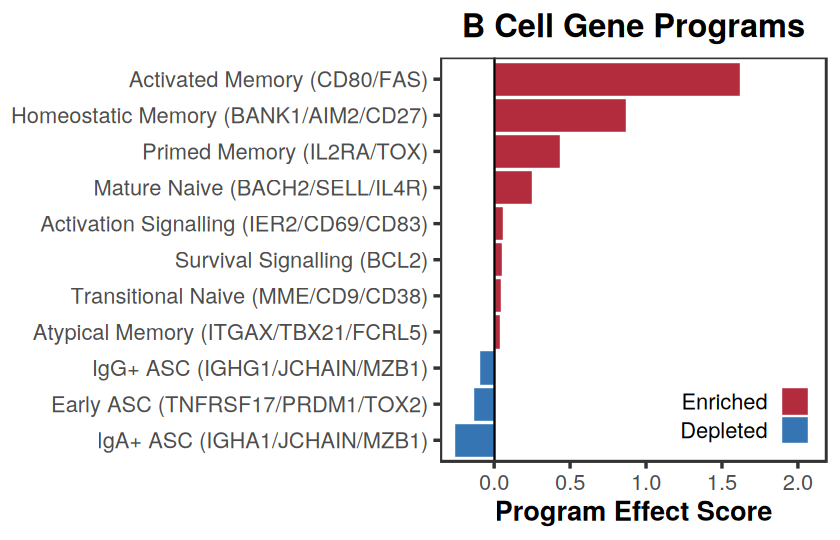

In [ ]:
options(repr.plot.width = 7, repr.plot.height = 4.5)

data <- map_dfr(
  .x = grep(pattern = "Housekeeping|Contamination|Artefactual", x = colnames(shap), value = TRUE, invert = TRUE),
  .f = function(x,
                shap.df = shap,
                gep.df = as.data.frame(t(gep.usage[["B"]]))[rownames(shap), , drop = FALSE],
                perturbation.scores = meld.stats[["Post"]][rownames(shap), "z", drop = TRUE],
                threshold = 0.2) {
    usage <- gep.df[[x]]
    shap.values <- shap.df[[x]]
    idx <- which(usage > threshold)
    mean.abs.shap <- mean(abs(shap.values[idx]))
    mean.perturbation <- mean(perturbation.scores[idx])
    return(list(
      program = x,
      mean_abs_shap = mean.abs.shap,
      mean_perturbation = mean.perturbation,
      program_effect_score = mean.abs.shap * mean.perturbation
    ))
  }
) %>%
  mutate(effect_direction = case_when(
    mean_perturbation > 0 ~ "Enriched",
    mean_perturbation < 0 ~ "Depleted",
    TRUE ~ "No change"
  ))

plot <- ggplot(data = data, mapping = aes(x = program_effect_score, y = reorder(program, program_effect_score), fill = effect_direction)) +
  geom_col(width = 0.95, color = "white", size = 0.3, alpha = 0.9) +
  labs(
    title = "B Cell Gene Programs",
    x = "Program Effect Score",
    y = NULL,
    fill = NULL
  ) +
  scale_x_continuous(expand = expansion(mult = c(0.05, 0.3))) +
  geom_vline(xintercept = 0, color = "black") +
  scale_fill_manual(
    values = c(
      "Depleted" = pals::brewer.rdbu(100)[90],
      "No change" = pals::brewer.rdbu(100)[50],
      "Enriched" = pals::brewer.rdbu(100)[10]
    ),
    breaks = c("Enriched", "Depleted")
  ) +
  theme_custom() +
  theme(
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    legend.position = "top",
    legend.title = element_text(face = "bold")
  ) +
  inset.legend(location = "bottomright")

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_b_program_effect_scores_bar.pdf",
  width = 7,
  height = 4.5,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

### Donor-level program score comparisons

In [ ]:
plots <- list()

### Naive B

In [ ]:
chosen.gep <- Features(sub[["GEP"]])[c(1, 4)]
chosen.gep

[1] "Mature Naive (BACH2/SELL/IL4R)"    "Transitional Naive (MME/CD9/CD38)"

In [ ]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

Inferred data type as 'sequential'. To override, set type explicitly.



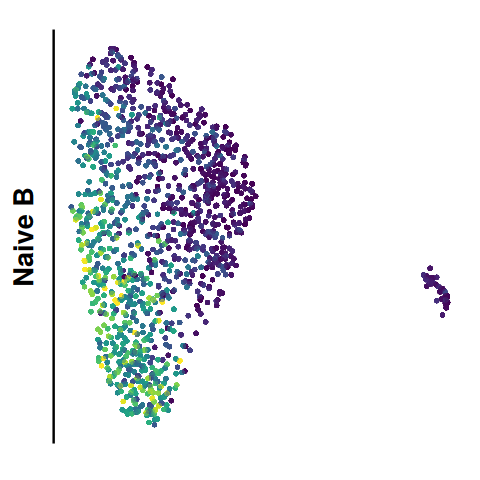

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 4)

plot <- embedding.plot(
  sub,
  colour = "program_score",
  cmap = pals::viridis(100),
  labs = list(y = "Naive B"),
  show.legend = FALSE,
  rasterise = TRUE,
  limits = c(NA, "p99"),
  size.adj = 15,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  geom_vline(xintercept = -Inf, color = "black", size = 1) +
  theme(
    panel.border = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_text(face = "bold"),
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_naive_b_program_score_umap.pdf",
  width = 4,
  height = 4,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

In [ ]:
data <- FetchData(sub, vars = c("donor", "condition", "cluster_coarse", "program_score")) %>%
  left_join(donor.metadata, by = "donor")

data.summary <- data %>%
  group_by(donor, condition) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [ ]:
model <- lmerTest::lmer(
  program_score ~ condition + age + sex + (1 | donor),
  data = data.summary
)

In [ ]:
emm <- emmeans::emmeans(model, ~ condition, lmer.df = "Satterthwaite")

contrasts <- list(
  "Post vs Pre" = c(-1, 1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.45
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Post vs Pre,-0.01078916,0.02624118,8,-0.07130143,0.0497231,-0.411154,0.6917531,0.6917531,p = 0.692 ns,Post,Pre,0.45


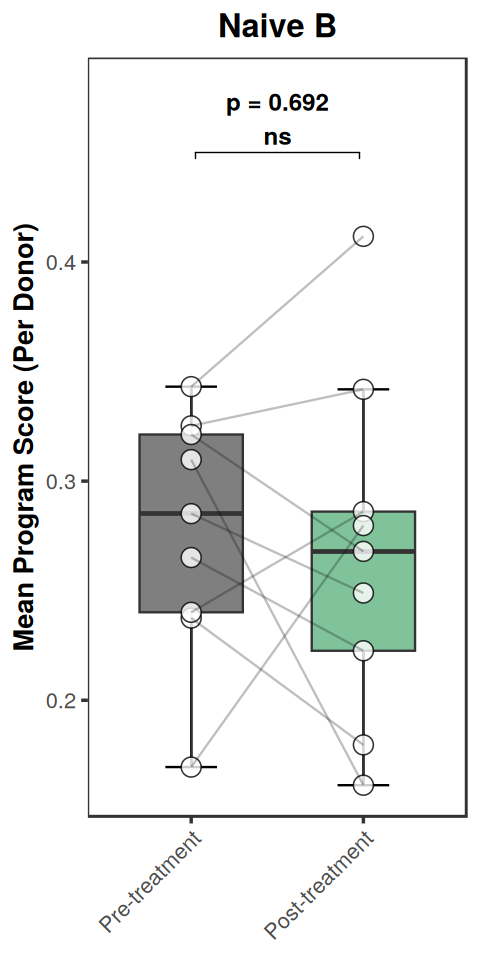

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 8)

plots[[1]] <- ggplot(data = data.summary, mapping = aes(x = condition, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = condition),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    data = data.summary,
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    data = data.summary,
    mapping = aes(group = donor),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(labels = c("Pre" = "Pre-treatment", "Post" = "Post-treatment")) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c("grey50", pals::brewer.qualseq(8)[4])) +
  labs(
    title = "Naive B",
    subtitle = NULL,
    x = NULL,
    y = "Mean Program Score (Per Donor)"
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold", color = "grey20", margin = margin(6, 6, 6, 6)),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    panel.spacing = unit(5, "mm")
  )

plots[[1]]

### Memory B

In [ ]:
chosen.gep <- Features(sub[["GEP"]])[c(2, 5, 6, 9)]
chosen.gep

[1] "Homeostatic Memory (BANK1/AIM2/CD27)"
[2] "Primed Memory (IL2RA/TOX)"           
[3] "Activated Memory (CD80/FAS)"         
[4] "Atypical Memory (ITGAX/TBX21/FCRL5)"

In [ ]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

Inferred data type as 'sequential'. To override, set type explicitly.



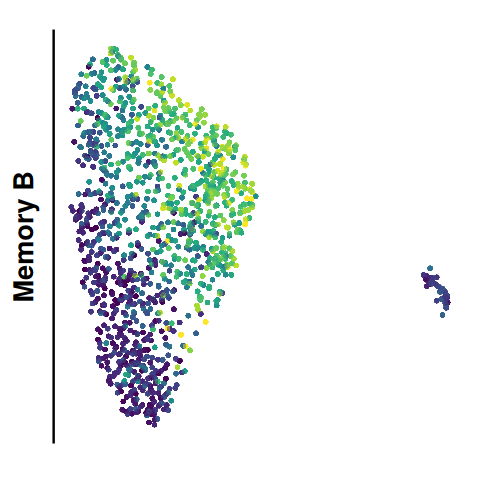

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 4)

plot <- embedding.plot(
  sub,
  colour = "program_score",
  cmap = pals::viridis(100),
  labs = list(y = "Memory B"),
  show.legend = FALSE,
  rasterise = TRUE,
  limits = c(NA, "p99"),
  size.adj = 15,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  geom_vline(xintercept = -Inf, color = "black", size = 1) +
  theme(
    panel.border = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_text(face = "bold"),
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_memory_b_program_score_umap.pdf",
  width = 4,
  height = 4,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

In [ ]:
data <- FetchData(sub, vars = c("donor", "condition", "cluster_coarse", "program_score")) %>%
  left_join(donor.metadata, by = "donor")

data.summary <- data %>%
  group_by(donor, condition) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [ ]:
model <- lmerTest::lmer(
  program_score ~ condition + age + sex + (1 | donor),
  data = data.summary
)

In [ ]:
emm <- emmeans::emmeans(model, ~ condition, lmer.df = "Satterthwaite")

contrasts <- list(
  "Post vs Pre" = c(-1, 1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.52
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Post vs Pre,0.06510261,0.02483135,8,0.007841423,0.1223638,2.621791,0.03056531,0.03056531,p = 0.031 *,Post,Pre,0.52


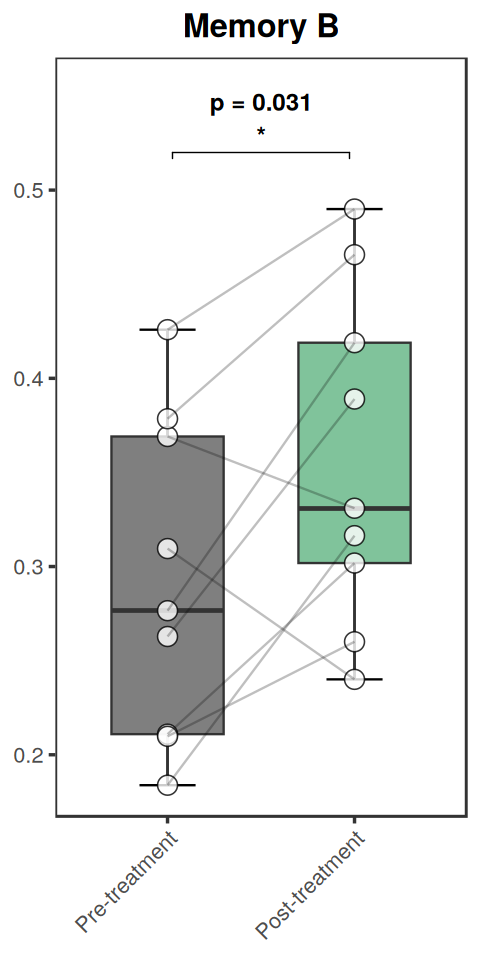

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 8)

plots[[2]] <- ggplot(data = data.summary, mapping = aes(x = condition, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = condition),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    data = data.summary,
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    data = data.summary,
    mapping = aes(group = donor),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(labels = c("Pre" = "Pre-treatment", "Post" = "Post-treatment")) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c("grey50", pals::brewer.qualseq(8)[4])) +
  labs(
    title = "Memory B",
    subtitle = NULL,
    x = NULL,
    y = NULL
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold", color = "grey20", margin = margin(6, 6, 6, 6)),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    panel.spacing = unit(5, "mm")
  )

plots[[2]]

### ASC

In [ ]:
chosen.gep <- Features(sub[["GEP"]])[c(10, 11, 12)]
chosen.gep

[1] "IgA+ ASC (IGHA1/JCHAIN/MZB1)"    "IgG+ ASC (IGHG1/JCHAIN/MZB1)"   
[3] "Early ASC (TNFRSF17/PRDM1/TOX2)"

In [ ]:
sub$program_score <- apply(GetAssayData(sub, assay = "GEP", layer = "data")[chosen.gep, ], 2, sum)

Inferred data type as 'sequential'. To override, set type explicitly.



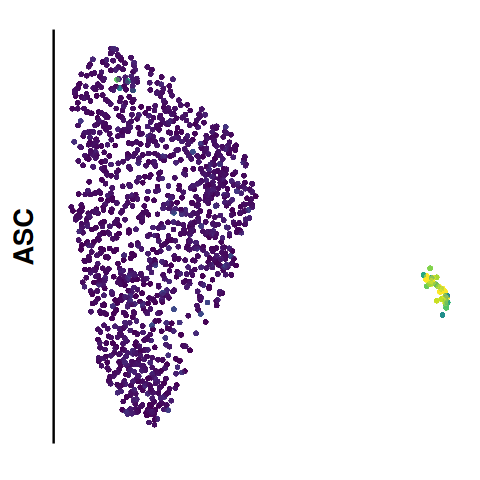

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 4)

plot <- embedding.plot(
  sub,
  colour = "program_score",
  cmap = pals::viridis(100),
  labs = list(y = "ASC"),
  show.legend = FALSE,
  rasterise = TRUE,
  limits = c(NA, "p99"),
  size.adj = 15,
  alpha = 1,
  pixels = c(2048, 2048)
) +
  geom_vline(xintercept = -Inf, color = "black", size = 1) +
  theme(
    panel.border = element_blank(),
    axis.title.x = element_blank(),
    axis.title.y = element_text(face = "bold"),
  )

plot

ggsave(
  plot = plot,
  filename = "../results/plots/kaufmann_asc_program_score_umap.pdf",
  width = 4,
  height = 4,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

In [ ]:
data <- FetchData(sub, vars = c("donor", "condition", "cluster_coarse", "program_score")) %>%
  left_join(donor.metadata, by = "donor")

data.summary <- data %>%
  group_by(donor, condition) %>%
  summarise(
    program_score = mean(program_score, na.rm = TRUE),
    age = first(age),
    sex = first(sex),
    .groups = "drop"
  )

In [ ]:
model <- lmerTest::lmer(
  program_score ~ condition + age + sex + (1 | donor),
  data = data.summary
)

In [ ]:
emm <- emmeans::emmeans(model, ~ condition, lmer.df = "Satterthwaite")

contrasts <- list(
  "Post vs Pre" = c(-1, 1)
)

stats <- emmeans::contrast(emm, method = contrasts, adjust = "none") %>%
  summary(infer = TRUE) %>%
  mutate(
    p.adj = p.adjust(p.value, method = "BH"),
    significance = case_when(
      p.adj < 0.001 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n***"),
      p.adj < 0.01 ~ glue::glue("p = {format(p.adj, scientific = TRUE, digits = 3)}\n**"),
      p.adj < 0.05 ~ glue::glue("p = {round(p.adj, 3)}\n*"),
      p.adj < 0.1 ~ glue::glue("p = {round(p.adj, 3)}\n."),
      TRUE ~ glue::glue("p = {round(p.adj, 3)}\nns")
    )
  ) %>%
  rowwise() %>%
  mutate(
    group1 = str_trim(str_split_i(contrast, " vs ", 1)),
    group2 = str_trim(str_split_i(contrast, " vs ", 2))
  ) %>%
  ungroup() %>%
  mutate(
    y.position = 0.11
  )

In [ ]:
stats

contrast,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,p.adj,significance,group1,group2,y.position
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<glue>,<chr>,<chr>,<dbl>
Post vs Pre,-0.01343695,0.01115014,8,-0.03914921,0.01227532,-1.205092,0.2626025,0.2626025,p = 0.263 ns,Post,Pre,0.11


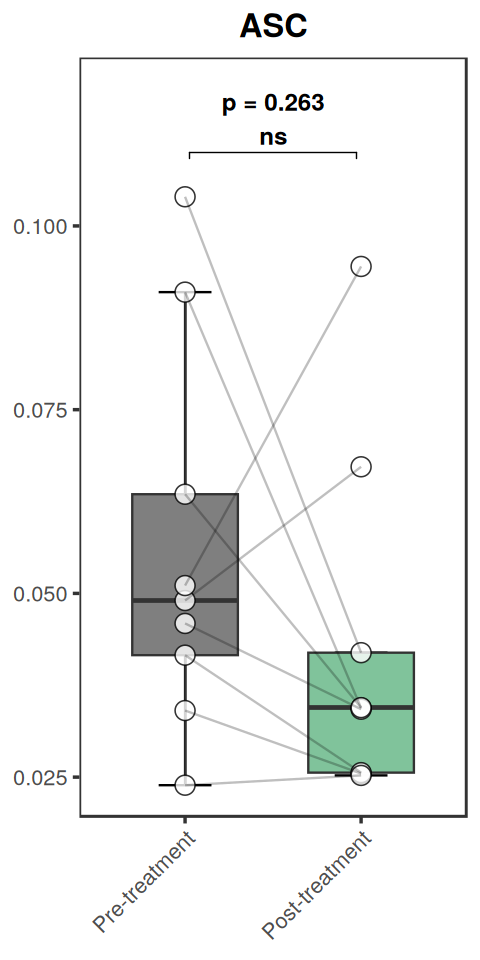

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 8)

plots[[3]] <- ggplot(data = data.summary, mapping = aes(x = condition, y = program_score)) +
  stat_boxplot(
    geom = "errorbar",
    width = 0.3
  ) +
  geom_boxplot(
    mapping = aes(fill = condition),
    width = 0.6,
    outlier.shape = NA,
    alpha = 1,
    size = 0.5
  ) +
  geom_point(
    data = data.summary,
    size = 5,
    alpha = 0.8,
    stroke = 0.5,
    shape = 21,
    fill = "white",
    color = "black"
  ) +
  geom_line(
    data = data.summary,
    mapping = aes(group = donor),
    color = "black",
    alpha = 0.25,
    linewidth = 0.5
  ) +
  ggpubr::stat_pvalue_manual(
    data = stats,
    label = "significance",
    fontface = "bold",
    size = 5,
    tip.length = 0.01,
    bracket.shorten = -0.05
  ) +
  scale_x_discrete(labels = c("Pre" = "Pre-treatment", "Post" = "Post-treatment")) +
  scale_y_continuous(expand = expansion(mult = c(0.05, 0.15))) +
  scale_fill_manual(values = c("grey50", pals::brewer.qualseq(8)[4])) +
  labs(
    title = "ASC",
    subtitle = NULL,
    x = NULL,
    y = NULL
  ) +
  theme_custom() +
  theme(
    strip.background = element_blank(),
    strip.text = element_text(size = 12, face = "bold", color = "grey20", margin = margin(6, 6, 6, 6)),
    strip.placement = "outside",
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    panel.spacing = unit(5, "mm")
  )

plots[[3]]

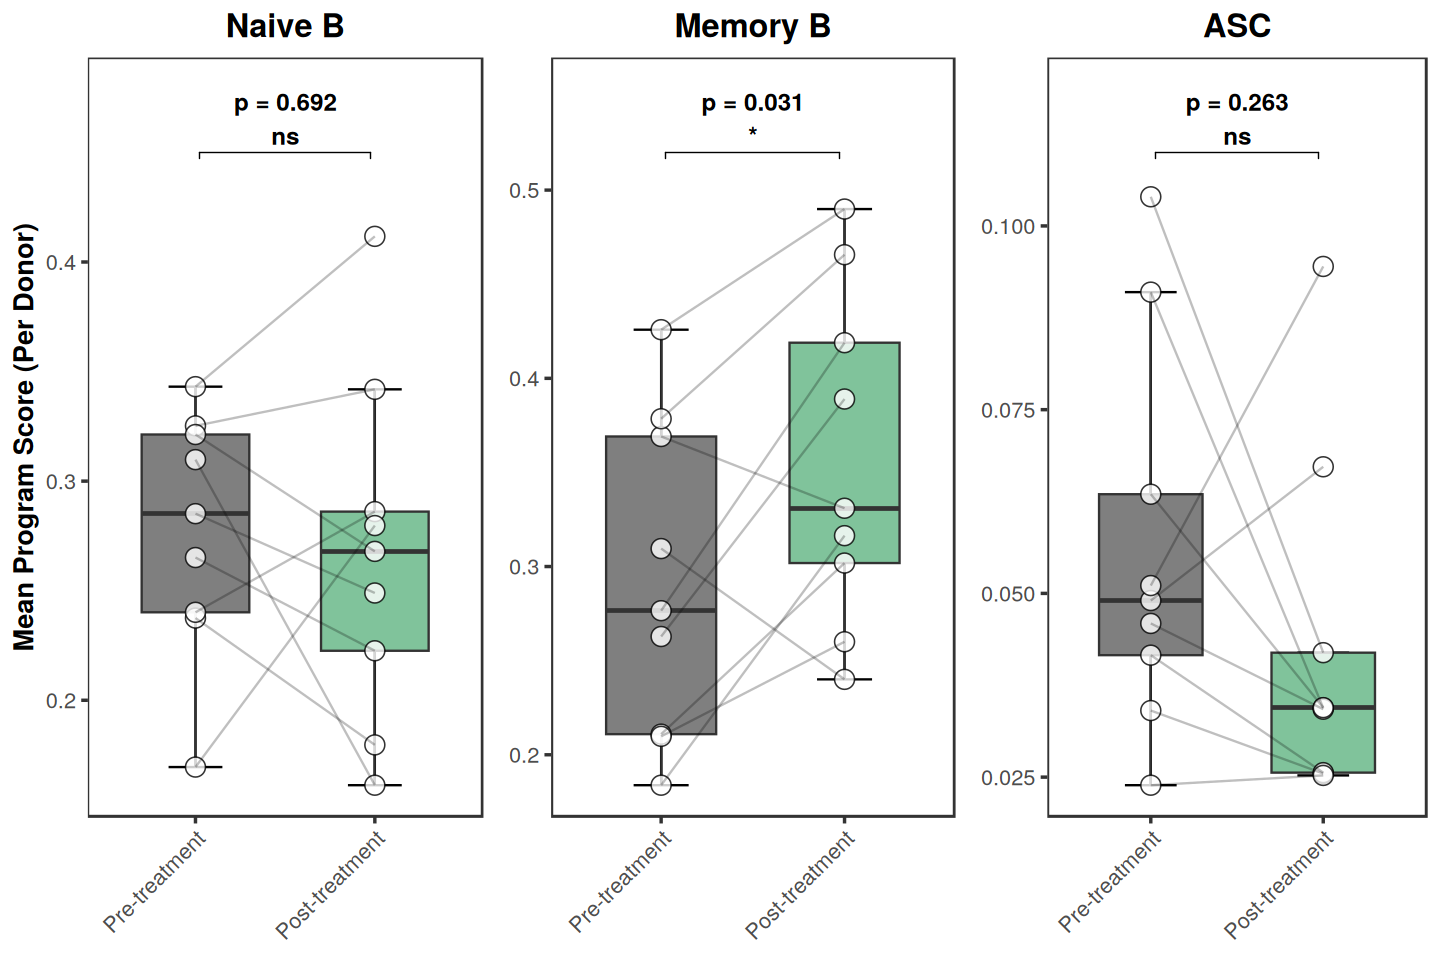

In [ ]:
options(repr.plot.width = 12, repr.plot.height = 8)

plot.combined <- plot_grid(plotlist = plots, nrow = 1, rel_widths = c(1.05, 1, 1))

plot.combined

ggsave(
  plot = plot.combined,
  filename = "../results/plots/kaufmann_t_program_scores_boxplot.pdf",
  width = 12,
  height = 8,
  units = "in",
  dpi = 300,
  device = cairo_pdf
)

# Session Info

In [42]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ComplexHeatmap_2.18.0 cowplot_1.1.3         patchwork_1.3.0      
 [4] ggExtra_0.11.0        lubridate_1.9.3       forcats_1.0.0        
 [7] stringr_1.5.1         dplyr_1.1.4           purrr_1.0.2          
[10] readr_2.1.5           tidyr_1.3.1           tibble_3.2.1         
[13] ggplot2_3.5.1         tidyverse_2.0.0       future_1.34.0        
[16] Seurat_5.1.0          SeuratObject_5.0.2    sp_2.1-4             

loaded via a namespace (and not attached):
  [1] RcppAnnoy_0.0.22       splines_4.3.3          later_1.3.2         